# Load libraries and define variables

In [ ]:
#####
# Load libraries
#####

suppressPackageStartupMessages(library("vegan"))
suppressPackageStartupMessages(library("ggplot2"))
suppressPackageStartupMessages(library("patchwork"))
suppressPackageStartupMessages(library("broom"))
suppressPackageStartupMessages(library("tidyverse"))
suppressPackageStartupMessages(library("rstatix"))
suppressPackageStartupMessages(library("data.table"))
suppressPackageStartupMessages(library("lme4"))
suppressPackageStartupMessages(library("KEGGREST"))
suppressPackageStartupMessages(library("mgcv"))
suppressPackageStartupMessages(library("future.apply"))
suppressPackageStartupMessages(library("glmmTMB"))
suppressPackageStartupMessages(library("performance"))
suppressPackageStartupMessages(library("httr"))

#####
# Define variables
#####
input_dir=c('XXXXX') ### Directory containing main tables from the Zenodo repository
output_tables=c('XXXXX') ### Directory to store tables produced by this script
output_figures=c('XXXXX') ### Directory to store figures produced by this script

subspecies_colours = c("Subspecies_0" = "#004949", "Subspecies_1" = "#ffb6db", "Subspecies_2" = "#9467bd", "Subspecies_3" = "#920000", "Subspecies_4" = "#6db6ff", "Subspecies_5" = "#009292", "Subspecies_6" = "#490092", "Subspecies_7" = "#006ddb", "Subspecies_8" = "#000000")
gene_level_cols = c("Universal" = "#4d4d4d", "Shared" = "#999999", "Unique" = "#e6e6e6")

Warning message:
“package ‘performance’ was built under R version 4.3.3”


# Assess population genome content variations

### Import and filter data to core content only

In [20]:
subspecies_core_gene_comp = fread(file=paste0(output_tables,"across_species/species_selected.subspecies.core_gene_list.tsv"), sep="\t", header=T)
subspecies_core_pfam_comp = fread(file=paste0(output_tables,"across_species/species_selected.subspecies.core_pfam_list.tsv"), sep="\t", header=T)


In [ ]:
subspecies_core_gene_comp = fread(file=paste0(output_tables,"across_species/species_selected.subspecies.core_gene_list.tsv"), sep="\t", header=T)
pop_core_genome_size = subspecies_core_gene_comp %>%
    select(Species, Subspecies, Gene_catalog_rep) %>%
    distinct() %>%
    group_by(Species,Subspecies) %>%
    summarise(
        Count = n_distinct(Gene_catalog_rep),
        .groups = "drop"
    )

### Visualise differences

In [22]:
### Assess the mean size of population core gene content

# Gene cluster
pop_core_genome_size = subspecies_core_gene_comp %>%
    select(Species, Subspecies, Gene_catalog_rep) %>%
    distinct() %>%
    group_by(Species,Subspecies) %>%
    summarise(
        Count = n_distinct(Gene_catalog_rep),
        .groups = "drop"
    )

pop_core_genome_size %>%
    summarise(
        mean = mean(Count),
        median = median(Count),
        sd_vals = sd(Count),
        se_vals = sd(Count, na.rm = TRUE) / sqrt(n()),
    )

# Pfam
pop_core_pfam_size = subspecies_core_pfam_comp %>%
    select(Species, Subspecies, PFAM_accession) %>%
    distinct() %>%
    group_by(Species,Subspecies) %>%
    summarise(
        Count = n_distinct(PFAM_accession),
        .groups = "drop"
    )

pop_core_pfam_size %>%
    summarise(
        mean = mean(Count),
        median = median(Count),
        sd_vals = sd(Count),
        se_vals = sd(Count, na.rm = TRUE) / sqrt(n()),
    )

mean,median,sd_vals,se_vals
<dbl>,<dbl>,<dbl>,<dbl>
2705.659,2262.5,1551.519,59.06532


mean,median,sd_vals,se_vals
<dbl>,<dbl>,<dbl>,<dbl>
1037.578,967,278.4307,10.59967


In [14]:
### Count number of subspecies per species
species_subspecies_count = subspecies_core_gene_comp %>%
    select(Species,Subspecies) %>%
    distinct() %>%
    select(-Subspecies) %>%
    group_by(Species) %>%
    summarise(Subspecies_count = n())

In [15]:
### Count number of subspecies per species
species_subspecies_count = subspecies_core_gene_comp %>%
    select(Species,Subspecies) %>%
    distinct() %>%
    select(-Subspecies) %>%
    group_by(Species) %>%
    summarise(Subspecies_count = n())

### Categorise universal, shared or unique amongst subspecies of the same species
# GENE CLUSTER
species_genes_subsp_categories_df = subspecies_core_gene_comp %>%
    select(Species, Subspecies, Gene_catalog_rep) %>%
    distinct() %>%
    select(-Subspecies) %>%
    group_by(Species, Gene_catalog_rep) %>%
    summarise(Count = n(), .groups = "drop") %>%
    left_join(species_subspecies_count, by = "Species") %>%
    mutate(Gene_group = case_when(
        Count == Subspecies_count ~ "Universal",
        Count < 2 ~ "Unique",
        TRUE ~ "Shared"
    ))
  
species_genes_subsp_categories_counts = species_genes_subsp_categories_df %>%
    select(Species, Gene_group) %>%
    group_by(Species, Gene_group) %>%
    summarise(Count = n(), .groups = "drop") %>%
    mutate(Gene_level = "Gene cluster")

# PFAM
species_pfam_pop_categories_df = subspecies_core_pfam_comp %>%
    filter(PFAM_accession != "-", !is.na(PFAM_accession)) %>%
    select(Species, Subspecies, PFAM_accession) %>%
    distinct() %>%
    select(-Subspecies) %>%
    group_by(Species, PFAM_accession) %>%
    summarise(Count = n(), .groups = "drop") %>%
    left_join(species_subspecies_count, by = "Species") %>%
    mutate(Gene_group = case_when(
        Count == Subspecies_count ~ "Universal",
        Count < 2 ~ "Unique",
        TRUE ~ "Shared"
    ))
 
subspecies_genes_and_pfams_categories_counts = species_pfam_pop_categories_df %>%
    select(Species, Gene_group) %>%
    group_by(Species, Gene_group) %>%
    summarise(Count = n(), .groups = "drop") %>%
    mutate(Gene_level = "Pfam family") %>%
    rbind(species_genes_subsp_categories_counts)

write.table(subspecies_genes_and_pfams_categories_counts,
            file = paste0(output_tables, "across_species/species_selected.subspecies.core_gene_and_pfam_counts.tsv"),
            sep = "\t", quote = FALSE, row.names = FALSE)

In [16]:
### Calculate proportions within each category
species_pct_universal = subspecies_genes_and_pfams_categories_counts %>%
    group_by(Species, Gene_level) %>%
    mutate(total_count = sum(Count)) %>%
    ungroup() %>%
    filter(Gene_group == "Universal") %>%
    mutate(pct_universal = 100 * Count / total_count)

universal_summary = species_pct_universal %>%
    group_by(Gene_level) %>%
    summarise(
        mean_pct = mean(pct_universal, na.rm = TRUE),
        sd_pct   = sd(pct_universal, na.rm = TRUE),
        se_pct   = sd(pct_universal, na.rm = TRUE) / sqrt(n()),
        n_species = n(),
        .groups = "drop"
    )

universal_summary

Gene_level,mean_pct,sd_pct,se_pct,n_species
<chr>,<dbl>,<dbl>,<dbl>,<int>
Gene cluster,70.42779,13.800662,0.8398815,270
Pfam family,94.29377,3.288503,0.2001319,270


In [17]:
head(subspecies_genes_and_pfams_categories_counts)

Species,Gene_group,Count,Gene_level
<chr>,<chr>,<int>,<chr>
1064_1,Shared,72,Pfam family
1064_1,Unique,37,Pfam family
1064_1,Universal,1469,Pfam family
1074_1,Unique,81,Pfam family
1074_1,Universal,1572,Pfam family
108_1,Unique,55,Pfam family


In [18]:
### Calculate the median values per group for visualisation
subspecies_genes_and_pfams_categories_median_vals = subspecies_genes_and_pfams_categories_counts %>%
    group_by(Gene_level, Gene_group) %>%
    summarise(
        mean_vals = mean(Count),
        median_vals = median(Count),
        sd_vals = sd(Count),
        se_vals = sd(Count, na.rm = TRUE) / sqrt(n()),
        .groups = "drop"
    ) %>%
    mutate(Gene_level = factor(Gene_level, levels = c("Gene cluster", "Pfam family"))) %>%
    mutate(Gene_group = factor(Gene_group, levels = c("Universal", "Shared", "Unique")))

subspecies_genes_and_pfams_categories_median_vals


Gene_level,Gene_group,mean_vals,median_vals,sd_vals,se_vals
<fct>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>
Gene cluster,Shared,931.52747,647.0,1137.33425,119.225025
Gene cluster,Unique,690.37407,513.5,552.72802,33.637956
Gene cluster,Universal,2134.25185,1765.0,1059.43178,64.474965
Pfam family,Shared,51.02198,42.0,33.09413,3.469208
Pfam family,Unique,45.32222,35.0,36.52666,2.222942
Pfam family,Universal,1010.42593,935.0,276.92769,16.853282


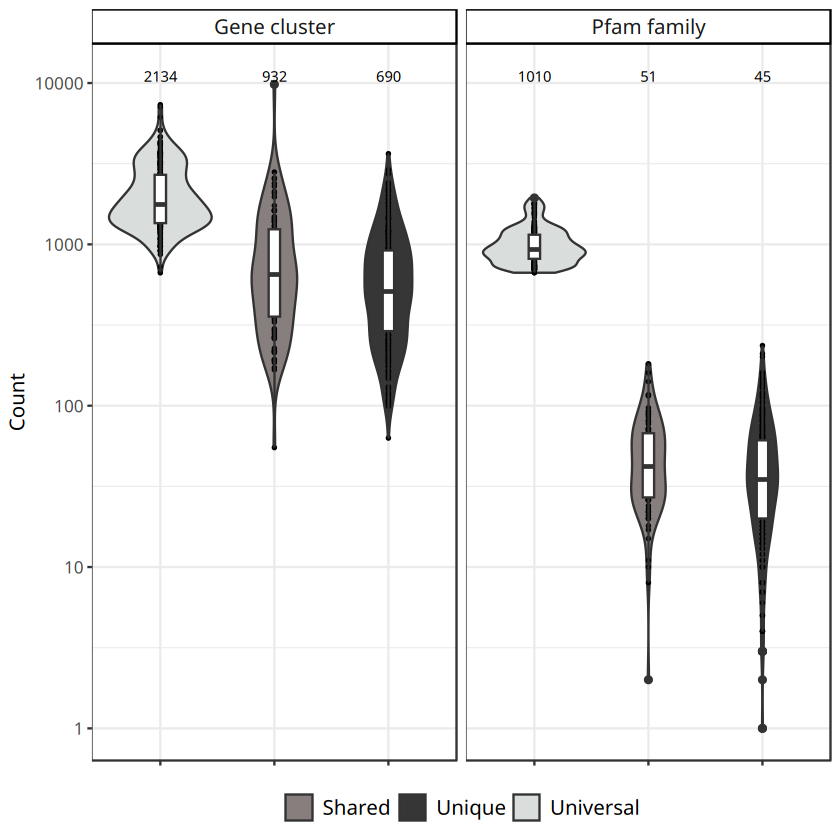

In [19]:
### Visualise
species_subsp_gene_comp_counts_violin = subspecies_genes_and_pfams_categories_counts %>%
    mutate(Gene_level = factor(Gene_level, levels = c("Gene cluster", "Pfam family"))) %>%
    ggplot(., aes(x = Gene_group, y = Count)) +
        geom_violin(aes(fill = Gene_group)) +
        geom_point(size = 0.5) +
        geom_boxplot(width = 0.1, linewidth = 0.5) +
        geom_text(
            data = subspecies_genes_and_pfams_categories_median_vals,
            aes(x = Gene_group, y = 11000, label = round(mean_vals, 0)),
            inherit.aes = FALSE,
            size = 3,
            color = "black"
        ) +
        scale_fill_manual(values = c("Universal" = "#D9DDDC", "Shared" = "#877F7D", "Unique" = "#363636")) +
        facet_grid(. ~ Gene_level, scales = "free_y") +
        scale_y_log10() +
        theme_bw() +
        theme(
            legend.position = "bottom",
            legend.title = element_blank(),
            legend.text = element_text(size = 12),
            strip.background.x = element_rect(fill = "white", colour = "black"),
            strip.text.x = element_text(size = 12),
            axis.text.y = element_text(size = 10),
            axis.title.y = element_text(size = 12),
            axis.title.x = element_blank(),
            axis.text.x = element_blank()
        ) +
        guides(fill = guide_legend(ncol = 3))
 
species_subsp_gene_comp_counts_violin

# Export figures
ggsave(paste0(output_figures,"across_species/species_selected.subspecies.gene_comp_counts_violinplot.pdf"), plot = species_subsp_gene_comp_counts_violin, device = "pdf", width=5, height=5, dpi = 300, units = "in")
ggsave(paste0(output_figures,"across_species/species_selected.subspecies.gene_comp_counts_violinplot.png"), plot = species_subsp_gene_comp_counts_violin, device = "png", width=5, height=5, dpi = 300, units = "in")

# Calculate gene content jaccard distances

## Import data

In [ ]:
subspecies_core_gene_comp = fread(file=paste0(output_tables,"across_species/species_selected.subspecies.core_gene_list.tsv"), sep="\t", header=T)
subspecies_core_pfam_comp = fread(file=paste0(output_tables,"across_species/species_selected.subspecies.core_pfam_list.tsv"), sep="\t", header=T)


## Calculate core genome jaccard distances

In [10]:
# Function to build presence/absence matrix and compute jaccard distance between subspecies of same species
compute_jaccard_by_species <- function(df,
                                        feature_col,
                                        species_col = "Species",
                                        pop_col     = "Subspecies",
                                        drop_missing = TRUE) {
 
  if (drop_missing) {
    df <- df %>%
      filter(.data[[feature_col]] != "-", !is.na(.data[[feature_col]]))
  }
 
  ## keep only distinct (species, population, feature) combos -
  ## multiple genes mapping to the same PFAM in the same population
  ## should collapse to a single presence, not be counted twice
  df_distinct <- df %>%
    distinct(.data[[species_col]], .data[[pop_col]], .data[[feature_col]])
 
  species_list <- unique(df_distinct[[species_col]])
  results <- list()
 
  for (sp in species_list) {
 
    sub <- df_distinct %>% filter(.data[[species_col]] == sp)
 
    ## need at least 2 subspecies to compute a distance
    if (length(unique(sub[[pop_col]])) < 2) next
 
    mat <- sub %>%
      mutate(present = 1L) %>%
      pivot_wider(
        id_cols     = all_of(pop_col),
        names_from  = all_of(feature_col),
        values_from = present,
        values_fill = 0L
      ) %>%
      column_to_rownames(pop_col) %>%
      as.matrix()
 
    results[[sp]] <- vegdist(mat, method = "jaccard", binary = TRUE)
  }
 
  results
}

# Convert list of dist objects into one tidy data frame
tidy_dist_list <- function(dist_list) {
  bind_rows(lapply(names(dist_list), function(sp) {
    m <- as.matrix(dist_list[[sp]])
    m[upper.tri(m, diag = TRUE)] <- NA   # keep only lower triangle (unique pairs)
 
    as.data.frame(as.table(m)) %>%
      filter(!is.na(Freq)) %>%
      rename(Subspecies_one = Var1,
             Subspecies_two = Var2,
             Jaccard_distance = Freq) %>%
      mutate(Species = sp, .before = 1)
  }))
}

In [ ]:
### Calculate jaccard distances

# a) Gene_catalog_rep level
subspecies_jaccard_distances_list <- compute_jaccard_by_species(
  subspecies_core_gene_comp,
  feature_col  = "Gene_catalog_rep",
  drop_missing = FALSE   # gene IDs are never "-"
)
subspecies_jaccard_distances_df <- tidy_dist_list(subspecies_jaccard_distances_list)
 
# b) PFAM_accession level
subspecies_pfam_jaccard_distances_list <- compute_jaccard_by_species(
  subspecies_core_pfam_comp,
  feature_col  = "PFAM_accession",
  drop_missing = TRUE    # exclude unannotated ("-") genes
)
subspecies_pfam_jaccard_distances_df <- tidy_dist_list(subspecies_pfam_jaccard_distances_list)

# Export
fwrite(subspecies_jaccard_distances_df, file=paste0(output_tables,"across_species/species_selected.subspecies.gene_jaccard_distances.tsv"), sep="\t", quote=F)
fwrite(subspecies_pfam_jaccard_distances_df, file=paste0(output_tables, "across_species/species_selected.subspecies.pfam_jaccard_distances.tsv"), sep="\t", quote=F)

Species,Subspecies_one,Subspecies_two,Jaccard_distance
<chr>,<fct>,<fct>,<dbl>
1064_1,Subspecies_1,Subspecies_0,0.05400254
1064_1,Subspecies_2,Subspecies_0,0.05852417
1064_1,Subspecies_3,Subspecies_0,0.05548469
1064_1,Subspecies_4,Subspecies_0,0.05994898
1064_1,Subspecies_2,Subspecies_1,0.01101036
1064_1,Subspecies_3,Subspecies_1,0.01295337
1064_1,Subspecies_4,Subspecies_1,0.01491569
1064_1,Subspecies_3,Subspecies_2,0.01493506
1064_1,Subspecies_4,Subspecies_2,0.01043705


## Visualise distributions of gene comp Jaccard distributions

In [ ]:
subspecies_jaccard_distances_df = fread(file=paste0(output_tables,"across_species/species_selected.subspecies.gene_jaccard_distances.tsv"), sep="\t", header=T)
subspecies_pfam_jaccard_distances_df = fread(file=paste0(output_tables, "across_species/species_selected.subspecies.pfam_jaccard_distances.tsv"), sep="\t", header=T)

In [22]:
subspecies_gene_between_dist = subspecies_jaccard_distances_df %>%
    mutate(Category = case_when(
        Subspecies_one == Subspecies_two ~ "Same subspecies",
        TRUE ~ "Different subspecies"
    )) %>%
    mutate(Gene_level = "Gene cluster") %>%
    filter(., Category == "Different subspecies")

subspecies_pfam_between_dist = subspecies_pfam_jaccard_distances_df %>%
    mutate(Category = case_when(
        Subspecies_one == Subspecies_two ~ "Same subspecies",
        TRUE ~ "Different subspecies"
    )) %>%
    mutate(Gene_level = "Pfam family") %>%
    filter(., Category == "Different subspecies")

gene_and_pfam_dist_between = rbind(subspecies_gene_between_dist,subspecies_pfam_between_dist)

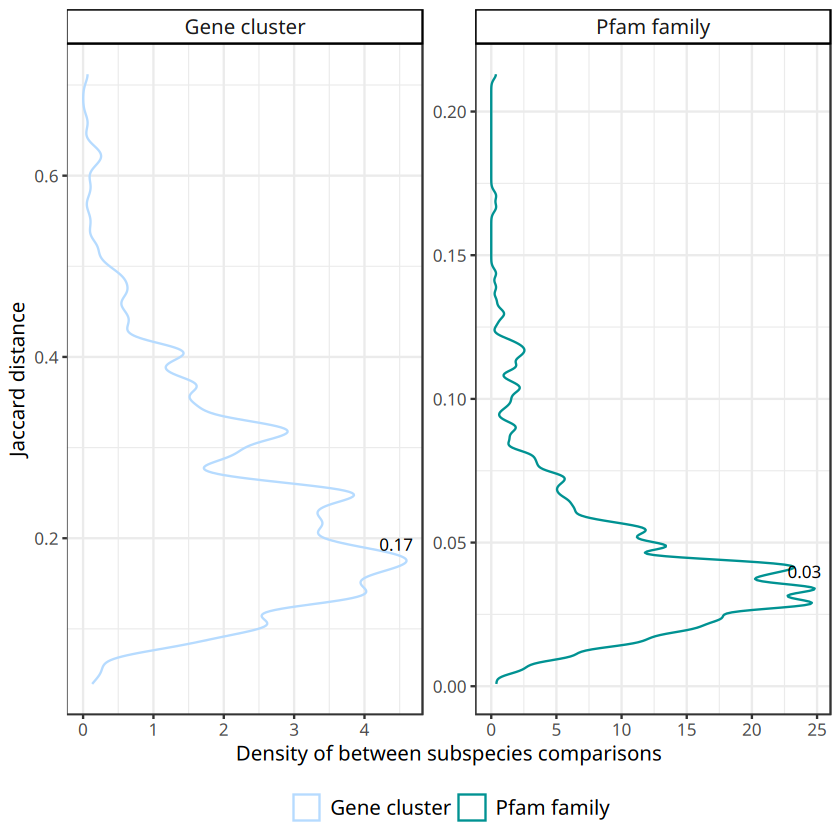

In [91]:
### Visualise distribution of jaccard distances between subspecies within species at gene cluster and pfam level
gene_comp_density = ggplot(gene_and_pfam_dist_between, aes(x = Jaccard_distance, colour = Gene_level)) +
  facet_wrap(.~Gene_level, scales = "free") +
  geom_density(adjust = 1/3) +
  scale_colour_manual(values=c("Gene cluster" = "#b6dbff", "Pfam family" = "#009292")) + 
  theme_bw() +
  labs(x = "Jaccard distance", y = "Density of between subspecies comparisons") +
  coord_flip() +           ## <-- added
  theme(
    axis.text.x = element_text(size = 10),
    axis.text.y = element_text(size = 10),
    axis.title.y = element_text(size = 12),
    axis.title.x = element_text(size = 12),
    strip.text.x = element_text(size = 12),
    strip.background.x = element_rect(fill = "white", colour = "black"),
    legend.position="bottom",
    legend.title = element_blank(),
    legend.text = element_text(size = 12)
  )

# Everything below is unchanged - peak_labels is computed from the
# pre-coord_flip data space, so it's unaffected by the flip
dens_data = ggplot_build(gene_comp_density)$data[[1]]

peak_labels = dens_data %>%
  group_by(group) %>% 
  slice_max(density, n = 1) %>%
  ungroup()

category_levels = unique(gene_and_pfam_dist_between$Gene_level)
peak_labels$Gene_level = factor(category_levels[peak_labels$group], levels = category_levels)

subspecies_gene_clust_pfam_jaccard_density = gene_comp_density + geom_text(
              data = peak_labels,
              aes(x = x, y = density, label = round(x, 2)),
              colour = "#000000",
              inherit.aes = FALSE,
              vjust = -0.8,
              hjust = 0.8,
              size = 3.5,
              show.legend=F)

subspecies_gene_clust_pfam_jaccard_density

# Export figures
ggsave(paste0(output_figures,"across_species/species_selected.gene_comp_jacc_dist_density.pdf"), plot = subspecies_gene_clust_pfam_jaccard_density, device = "pdf", width=5, height=5, units = "in")
ggsave(paste0(output_figures,"across_species/species_selected.gene_comp_jacc_dist_density.png"), plot = subspecies_gene_clust_pfam_jaccard_density, device = "png", width=5, height=5, units = "in")

# Calculate sample-based gene content jaccard distances

## Import data

In [ ]:
subspecies_core_gene_comp = fread(file=paste0(output_tables,"across_species/species_selected.subspecies.core_gene_list.tsv"), sep="\t", header=T)
subspecies_core_pfam_comp = fread(file=paste0(output_tables,"across_species/species_selected.subspecies.core_pfam_list.tsv"), sep="\t", header=T)
species_gene_cat_profile = fread(file = paste0(input_dir,"species_selected.gene_catalog.tsv"), sep = "\t", header=T, check.names=F)
species_subsp_gene_comp = fread(file = paste0(input_dir,"species_selected.gene_composition_w_annotations.tsv"), sep = "\t", header=T, check.names=F)

In [ ]:
# Add PFAM annotation to gene catalog profile
gene_to_pfam <- species_subsp_gene_comp %>%
  select(Gene_catalog_rep,PFAM_accession) %>%
  distinct()

species_gene_cat_profile_w_pfam = species_gene_cat_profile %>%
    left_join(gene_to_pfam, by="Gene_catalog_rep")

# Create sample to population mapping file
samp_to_subsp = species_gene_cat_profile %>%
  select(Sample,Species,Subspecies) %>%
  distinct()

## Calculate distances

In [41]:
### Compute Jaccard distance by sample
compute_jaccard_by_sample <- function(df,
                                       feature_col,
                                       species_col = "Species",
                                       sample_col  = "Sample",
                                       drop_missing = TRUE) {
 
  if (drop_missing) {
    df <- df %>%
      filter(.data[[feature_col]] != "-", !is.na(.data[[feature_col]]))
  }
 
  df_distinct <- df %>%
    distinct(.data[[species_col]], .data[[sample_col]], .data[[feature_col]])
 
  species_list <- unique(df_distinct[[species_col]])
  results <- list()
 
  for (sp in species_list) {
 
    sub <- df_distinct %>% filter(.data[[species_col]] == sp)
 
    if (length(unique(sub[[sample_col]])) < 2) next
 
    mat <- sub %>%
      mutate(present = 1L) %>%
      pivot_wider(
        id_cols     = all_of(sample_col),
        names_from  = all_of(feature_col),
        values_from = present,
        values_fill = 0L
      ) %>%
      column_to_rownames(sample_col) %>%
      as.matrix()
 
    results[[sp]] <- vegdist(mat, method = "jaccard", binary = TRUE)
  }
 
  results
}

### Convert list to data frame
tidy_dist_list_samples <- function(dist_list) {
  bind_rows(lapply(names(dist_list), function(sp) {
    m <- as.matrix(dist_list[[sp]])
    m[upper.tri(m, diag = TRUE)] <- NA
 
    as.data.frame(as.table(m)) %>%
      filter(!is.na(Freq)) %>%
      rename(Sample_one = Var1,
             Sample_two = Var2,
             Jaccard_distance = Freq) %>%
      mutate(Species = sp, .before = 1)
  }))
}

In [ ]:
### Apply functions
core_sample_table <- species_gene_cat_profile_w_pfam  %>%
  semi_join(subspecies_core_gene_comp, by = c("Species", "Subspecies", "Gene_catalog_rep"))
 
jaccard_gene_sample_list <- compute_jaccard_by_sample(
  core_sample_table,
  feature_col  = "Gene_catalog_rep",
  drop_missing = FALSE
)

jaccard_gene_sample_df <- tidy_dist_list_samples(jaccard_gene_sample_list) %>%
  left_join(samp_to_subsp, by=c("Sample_one" = "Sample","Species")) %>%
  rename(Subspecies_one = Subspecies) %>%
  left_join(samp_to_subsp, by=c("Sample_two" = "Sample","Species")) %>%
  rename(Subspecies_two = Subspecies)

fwrite(jaccard_gene_sample_df, file=paste0(output_tables,"across_species/species_selected.subspecies.sample_gene_jaccard_distances.tsv"), sep="\t", quote=F)

core_sample_table_pfam = species_gene_cat_profile_w_pfam %>%
    filter(PFAM_accession != "-", !is.na(PFAM_accession)) %>%
    semi_join(subspecies_core_pfam_comp, by = c("Species", "Subspecies", "PFAM_accession"))

jaccard_pfam_sample_list <- compute_jaccard_by_sample(
  core_sample_table_pfam,
  feature_col  = "PFAM_accession",
  drop_missing = FALSE
)
jaccard_pfam_sample_df <- tidy_dist_list_samples(jaccard_pfam_sample_list) %>%
  left_join(samp_to_subsp, by=c("Sample_one" = "Sample","Species")) %>%
  rename(Subspecies_one = Subspecies) %>%
  left_join(samp_to_subsp, by=c("Sample_two" = "Sample","Species")) %>%
  rename(Subspecies_two = Subspecies)

fwrite(jaccard_pfam_sample_df, file=paste0(output_tables,"across_species/species_selected.subspecies.sample_pfam_jaccard_distances.tsv"), sep="\t", quote=F)


# Compare sample-level SNV dist with gene comp jaccard

## Import data

In [ ]:
#####
# Compare SNV and gene composition jaccard distance - SAMPLE LEVEL
#####

# import
subspecies_sample_snv_dist = fread(file = paste0(input_dir,"POPULATIONS-DIST-SUMMARY.tsv.gz"), sep = "\t", header=T, check.names=F) %>%
    mutate(
        Subspecies_one = paste0("Subspecies_",cluster_1),
        Subspecies_two = paste0("Subspecies_",cluster_2),
        Category = case_when(
            comp == "Same population" ~ "Same subspecies",
            comp == "Different populations" ~ "Different subspecies")
    ) %>%
    rename(
        Species = species,
        Sample_one = sample_1,
        Sample_two = sample_2,
        SNV_distance = dist)

jaccard_gene_sample_df = fread(file=paste0(output_tables,"across_species/species_selected.subspecies.sample_gene_jaccard_distances.tsv"), sep="\t", header=T)
jaccard_pfam_sample_df = fread(file=paste0(output_tables,"across_species/species_selected.subspecies.sample_pfam_jaccard_distances.tsv"), sep="\t", header=T)


## Sample SNV distances

Saving 6.67 x 6.67 in image
Saving 6.67 x 6.67 in image


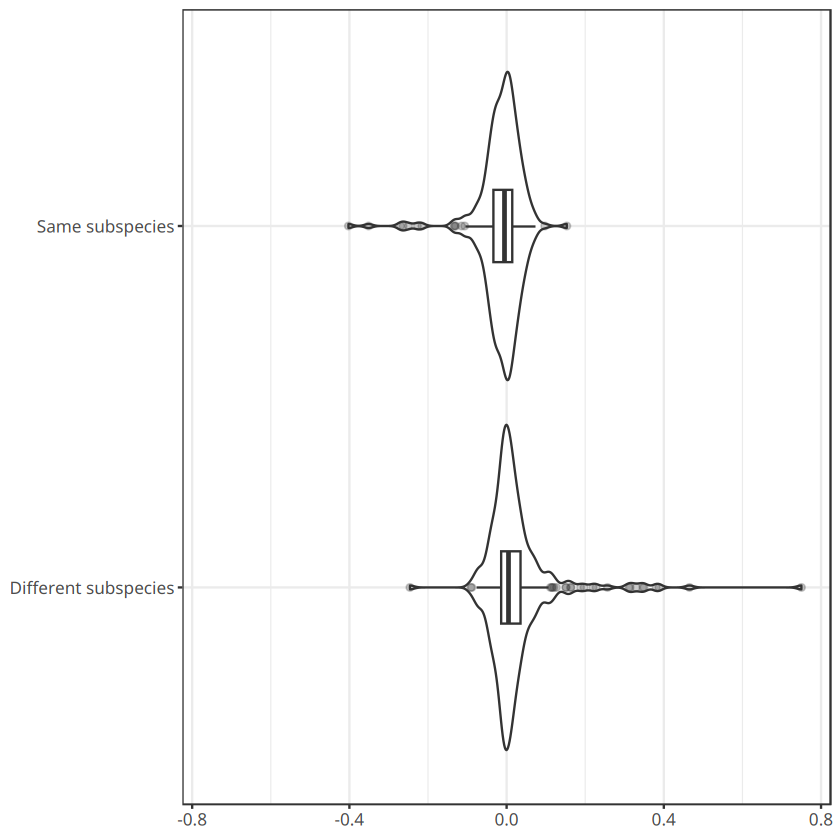

In [67]:
#####

### Compare SNV distances between and within subspecies

#####

### Species mean-normalised distances
species_subspsample_snv_distance_mean = subspecies_sample_snv_dist %>%
    aggregate(SNV_distance~Species, data=., FUN=mean) %>%
    rename(mean_snv_distance = SNV_distance)

species_subspsample_snv_distance_normalised = subspecies_sample_snv_dist %>%
    aggregate(SNV_distance~Species+Category, data=., FUN=mean) %>%
    rename(mean_cat_snv_distance = SNV_distance) %>%
    left_join(species_subspsample_snv_distance_mean, by=c("Species")) %>%
    mutate(normalised_snv_distance = (mean_cat_snv_distance/mean_snv_distance)-1) %>%
    mutate(Category = factor(Category, levels=c("Different subspecies","Same subspecies"))) %>%
    mutate(normalised_snv_distance_mod = case_when(
        normalised_snv_distance > 0.75 ~ 0.75,
        normalised_snv_distance < -0.75 ~ -0.75,
        TRUE ~ normalised_snv_distance
    ))

species_subspsample_snv_distance_normalised_violin = 
    ggplot(data=species_subspsample_snv_distance_normalised, aes(y = Category, x = normalised_snv_distance_mod)) + 
        geom_violin() + 
        geom_boxplot(width = 0.2, alpha = 0.25) +
        scale_x_continuous(limits=c(-0.75,0.75)) +  
        labs(x = "Species mean-normalised SNV distance between subspecies") + 
        theme_bw() + 
        theme(legend.position="bottom",
            strip.background.y = element_rect(fill = "white", colour = "black"),
            strip.text.y = element_text(size = 12),
            axis.text.y = element_text(size = 10),
            axis.title.y = element_blank(),
            axis.title.x = element_blank(),
            axis.text.x = element_text(size = 10))     
species_subspsample_snv_distance_normalised_violin

# Export figures
ggsave(paste0(output_figures,"across_species/species_selected.subspecies.within_vs_between_snv_dist_norm_violinplot.pdf"), plot = species_subspsample_snv_distance_normalised_violin, device = "pdf", dpi = 300, units = "in")
ggsave(paste0(output_figures,"across_species/species_selected.subspecies.within_vs_between_snv_dist_norm_violinplot.png"), plot = species_subspsample_snv_distance_normalised_violin, device = "png", dpi = 300, units = "in")

## Subspecies gene comp Jaccard distances

In [69]:
#####
# Compare sample gene content jaccard distance between and within subspecies
#####

subspecies_jaccard_distances_df_mod = jaccard_gene_sample_df %>%
    mutate(Gene_level = "Gene cluster") %>%
    mutate(Category = case_when(
        Subspecies_one == Subspecies_two ~ "Same subspecies",
        TRUE ~ "Different subspecies"
    ))

subspecies_gene_and_pfam_dist = jaccard_pfam_sample_df %>%
    mutate(Gene_level = "Pfam family") %>%
    mutate(Category = case_when(
        Subspecies_one == Subspecies_two ~ "Same subspecies",
        TRUE ~ "Different subspecies"
    )) %>%
    rbind(subspecies_jaccard_distances_df_mod)

In [70]:
### What is the distribution of divergence observed between subspecies?

get_density_peak = function(x) {
    d = density(x, na.rm = TRUE)
    d$x[which.max(d$y)]
}

subspecies_gene_and_pfam_dist %>%
    filter(Category == "Different subspecies") %>%
    aggregate(Jaccard_distance~Species+Subspecies_one+Subspecies_two+Gene_level, data=., FUN=mean) %>%
    group_by(Gene_level) %>%
    summarise(
        peak_jaccard = get_density_peak(Jaccard_distance),
        median_jaccard = median(Jaccard_distance, na.rm = TRUE),
        sd_jaccard = sd(Jaccard_distance, na.rm = TRUE),
        n = n()
    )

### Is there substantial differences within vs. between subspecies?
paired_category_test = subspecies_gene_and_pfam_dist %>%
    aggregate(Jaccard_distance ~ Species + Category + Gene_level, data = ., FUN = mean) %>%
    pivot_wider(names_from = Category, values_from = Jaccard_distance) %>%
    drop_na()

paired_category_test %>%
    group_by(Gene_level) %>%
    summarise(
        wilcox_p = wilcox.test(`Different subspecies`, `Same subspecies`, paired = TRUE)$p.value,
        median_diff = median(`Different subspecies` - `Same subspecies`, na.rm = TRUE),
        n_species = n()
    )

Gene_level,peak_jaccard,median_jaccard,sd_jaccard,n
<chr>,<dbl>,<dbl>,<dbl>,<int>
Gene cluster,0.17064033,0.22047862,0.11189249,1379
Pfam family,0.03244888,0.03814262,0.02632694,1379


Gene_level,wilcox_p,median_diff,n_species
<chr>,<dbl>,<dbl>,<int>
Gene cluster,4.954908e-46,0.2291747,270
Pfam family,4.954908e-46,0.0413402,270


In [71]:
### Compare intra- versus inter-population distances 
# Calculate species mean 
species_mean_jaccard = subspecies_gene_and_pfam_dist %>%
    aggregate(Jaccard_distance ~ Species + Gene_level, data = ., FUN = mean) %>%
    rename(mean_species_jaccard = Jaccard_distance)

# Calculate intra- versus inter-population distances normalised by species mean
species_subspgene_and_pfam_distance_normalised = subspecies_gene_and_pfam_dist %>%
    aggregate(Jaccard_distance ~ Species + Category + Gene_level, data = ., FUN = mean) %>%
    rename(mean_cat_jaccard_distance = Jaccard_distance) %>%
    left_join(species_mean_jaccard, by = c("Species", "Gene_level")) %>%
    mutate(normalised_jaccard = (mean_cat_jaccard_distance / mean_species_jaccard) - 1) %>%
    mutate(Category = factor(Category, levels = c("Different subspecies", "Same subspecies"))) %>%
    mutate(Gene_level = factor(Gene_level, levels = c("Gene cluster", "Pfam family"))) %>%
    mutate(normalised_jaccard_mod = case_when(
        normalised_jaccard > 1.5 ~ 1.5,
        TRUE ~ normalised_jaccard
    )) %>%
    arrange(Species,Category)

Saving 6.67 x 6.67 in image
Saving 6.67 x 6.67 in image


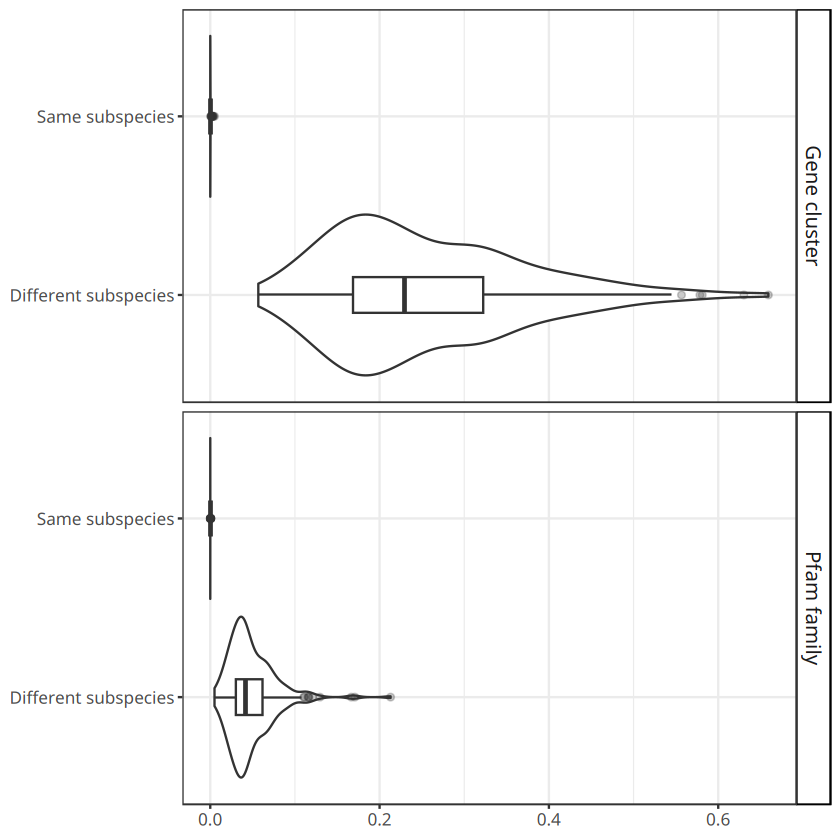

In [72]:
species_subspcore_gene_and_pfam_jaccard_violin = 
    ggplot(data=species_subspgene_and_pfam_distance_normalised, aes(y = Category, x = mean_cat_jaccard_distance)) + 
        geom_violin(scale = "width", adjust = 1) + 
        geom_boxplot(width = 0.2, alpha = 0.25) +
        facet_grid(Gene_level~.) +
        # scale_x_continuous(limits=c(-1,1)) +
        # coord_cartesian(xlim = c(-1, 1.5)) +  
        labs(x = "Species mean-normalised Jaccard distance between subspecies") + 
        theme_bw() + 
        theme(legend.position="bottom",
            strip.background.y = element_rect(fill = "white", colour = "black"),
            strip.text.y = element_text(size = 12),
            axis.text.y = element_text(size = 10),
            axis.title.y = element_blank(),
            axis.title.x = element_blank(),
            axis.text.x = element_text(size = 10))   
species_subspcore_gene_and_pfam_jaccard_violin

# Export figures
ggsave(paste0(output_figures,"across_species/species_selected.subspecies.within_vs_between_gene_comp_jacc_dist_violinplot.pdf"), plot = species_subspcore_gene_and_pfam_jaccard_violin, device = "pdf", dpi = 300, units = "in")
ggsave(paste0(output_figures,"across_species/species_selected.subspecies.within_vs_between_gene_comp_jacc_dist_violinplot.png"), plot = species_subspcore_gene_and_pfam_jaccard_violin, device = "png", dpi = 300, units = "in")

Saving 6.67 x 6.67 in image
Saving 6.67 x 6.67 in image


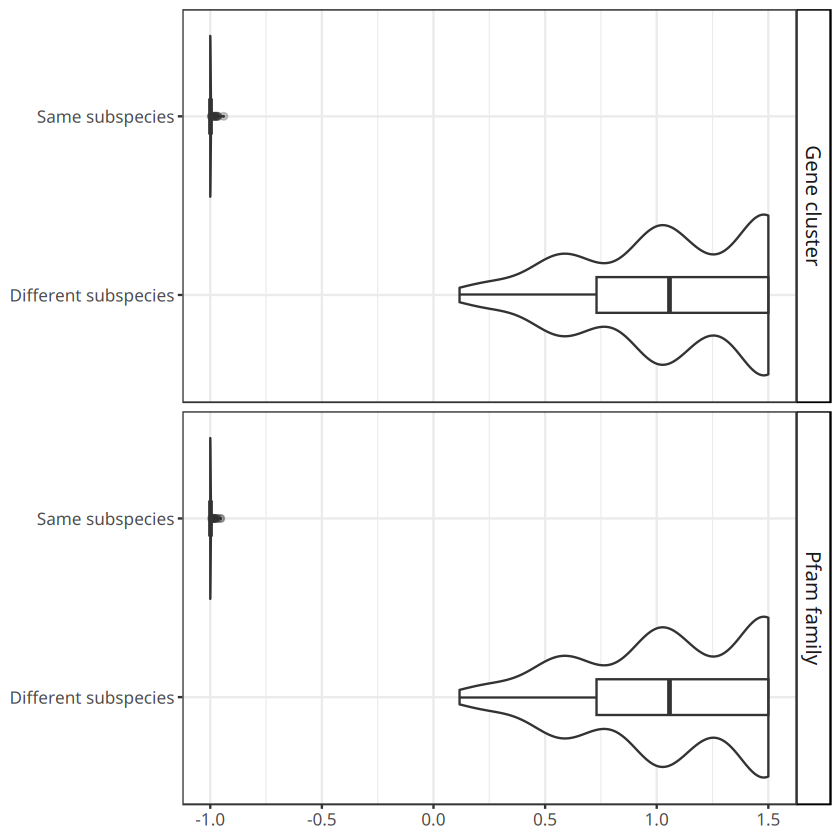

In [73]:
### Visualised a version with species-mean normalised distances
species_subspcore_gene_and_pfam_jaccard_violin_norm = 
    ggplot(data=species_subspgene_and_pfam_distance_normalised, aes(y = Category, x = normalised_jaccard_mod)) + 
        geom_violin(scale = "width", adjust = 1) + 
        geom_boxplot(width = 0.2, alpha = 0.25) +
        facet_grid(Gene_level~.) +
        # scale_x_continuous(limits=c(-1,1)) +
        # coord_cartesian(xlim = c(-1, 1.5)) +  
        labs(x = "Species mean-normalised Jaccard distance between subspecies") + 
        theme_bw() + 
        theme(legend.position="bottom",
            strip.background.y = element_rect(fill = "white", colour = "black"),
            strip.text.y = element_text(size = 12),
            axis.text.y = element_text(size = 10),
            axis.title.y = element_blank(),
            axis.title.x = element_blank(),
            axis.text.x = element_text(size = 10))   
species_subspcore_gene_and_pfam_jaccard_violin_norm

# Export figures
ggsave(paste0(output_figures,"across_species/species_selected.subspecies.within_vs_between_gene_comp_jacc_dist_norm_violinplot.pdf"), plot = species_subspcore_gene_and_pfam_jaccard_violin_norm, device = "pdf", dpi = 300, units = "in")
ggsave(paste0(output_figures,"across_species/species_selected.subspecies.within_vs_between_gene_comp_jacc_dist_norm_violinplot.png"), plot = species_subspcore_gene_and_pfam_jaccard_violin_norm, device = "png", dpi = 300, units = "in")

## SNV vs. gene comp Jaccard

In [75]:
### Extract only inter-population values from SNV and Jaccard distances

subspecies_gene_and_pfam_diff_dist = subspecies_gene_and_pfam_dist %>%
    filter(Category == "Different subspecies") %>%
    aggregate(Jaccard_distance~Species+Subspecies_one+Subspecies_two+Gene_level, data=., FUN=mean)
species_subspsnv_diff_dist = subspecies_sample_snv_dist %>%
    filter(Category == "Different subspecies") %>%
    aggregate(SNV_distance~Species+Subspecies_one+Subspecies_two, data=., FUN=mean)

### Create a single dataframe for gene cluster + SNV distance and for pfam + SNV distance
pairwise_jaccard = subspecies_gene_and_pfam_diff_dist %>%
    left_join(
        species_subspsnv_diff_dist %>%
            select(Species, Subspecies_one, Subspecies_two, SNV_distance),
        by = c("Species", "Subspecies_one", "Subspecies_two")
    )

gene_data = pairwise_jaccard %>% 
    filter(Gene_level == "Gene cluster", !is.na(SNV_distance), !is.na(Jaccard_distance))
pfam_data = pairwise_jaccard %>% 
    filter(Gene_level == "Pfam family", !is.na(SNV_distance), !is.na(Jaccard_distance))

In [76]:
### Test the relationship between jaccard and SNV distance through different models
fit_and_compare_models = function(data, group_label) {
 
    ## mgcv's s(..., bs = "re") requires the grouping variable to be
    ## a factor - a character column (common after fread()) causes
    ## an opaque internal error during smooth construction
    data = data %>% mutate(Species = as.factor(Species))
 
    ## Linear and quadratic mixed models - both fit with ML (REML=FALSE)
    ## so they can be validly compared via AIC/LRT
    lm_fit = lmerTest::lmer(
        Jaccard_distance ~ SNV_distance + (1 | Species),
        data = data, REML = FALSE
    )
 
    poly_fit = lmerTest::lmer(
        Jaccard_distance ~ poly(SNV_distance, 2) + (1 | Species),
        data = data, REML = FALSE
    )
 
    ## GAM with a flexible smooth term for SNV_distance, and Species
    ## handled as a random-intercept smooth (bs = "re") - the GAM
    ## equivalent of (1 | Species). method = "ML" for comparability
    ## with the ML-fit lmer models above.
    gam_fit = mgcv::gam(
        Jaccard_distance ~ s(SNV_distance, k = 5) + s(Species, bs = "re"),
        data = data, method = "ML"
    )
 
    ## Nested F/LRT test: is the quadratic term justified over linear?
    ## anova() on merMod objects with differing fixed effects
    ## automatically refits with ML if not already (here already ML)
    lrt_result = anova(lm_fit, poly_fit)
 
    comparison = data.frame(
        Gene_level   = group_label,
        lm_aic       = AIC(lm_fit),
        poly_aic     = AIC(poly_fit),
        gam_aic      = AIC(gam_fit),
        poly_p_value = lrt_result$`Pr(>Chisq)`[2],
        ## edf for the SNV_distance smooth specifically (first smooth
        ## term in the gam formula) - near 1 = effectively linear,
        ## notably >1 = real curvature
        gam_edf      = summary(gam_fit)$s.table["s(SNV_distance)", "edf"]
    )
 
    list(lm_fit = lm_fit, poly_fit = poly_fit, gam_fit = gam_fit, comparison = comparison)
}

gene_comparison = fit_and_compare_models(gene_data, "Gene cluster")
pfam_comparison = fit_and_compare_models(pfam_data, "Pfam family")
 
model_comparison_summary = bind_rows(gene_comparison$comparison, pfam_comparison$comparison)
model_comparison_summary

Warning message:
“Some predictor variables are on very different scales: consider rescaling”
Warning message:
“Some predictor variables are on very different scales: consider rescaling”
Warning message:
“Some predictor variables are on very different scales: consider rescaling”
Warning message:
“Some predictor variables are on very different scales: consider rescaling”


Gene_level,lm_aic,poly_aic,gam_aic,poly_p_value,gam_edf
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Gene cluster,-3060.361,-3068.108,-3486.345,0.001796367,2.682186
Pfam family,-6767.317,-6770.372,-7145.741,0.024556106,3.580202



Method: ML   Optimizer: outer newton
full convergence after 5 iterations.
Gradient range [-2.935285e-07,1.546787e-07]
(score -1536.017 & scale 0.003955334).
Hessian positive definite, eigenvalue range [0.4202046,711.3631].
Model rank =  275 / 275 

Basis dimension (k) checking results. Low p-value (k-index<1) may
indicate that k is too low, especially if edf is close to k'.

                    k'    edf k-index p-value
s(SNV_distance)   4.00   2.68    0.99    0.37
s(Species)      270.00 237.38      NA      NA


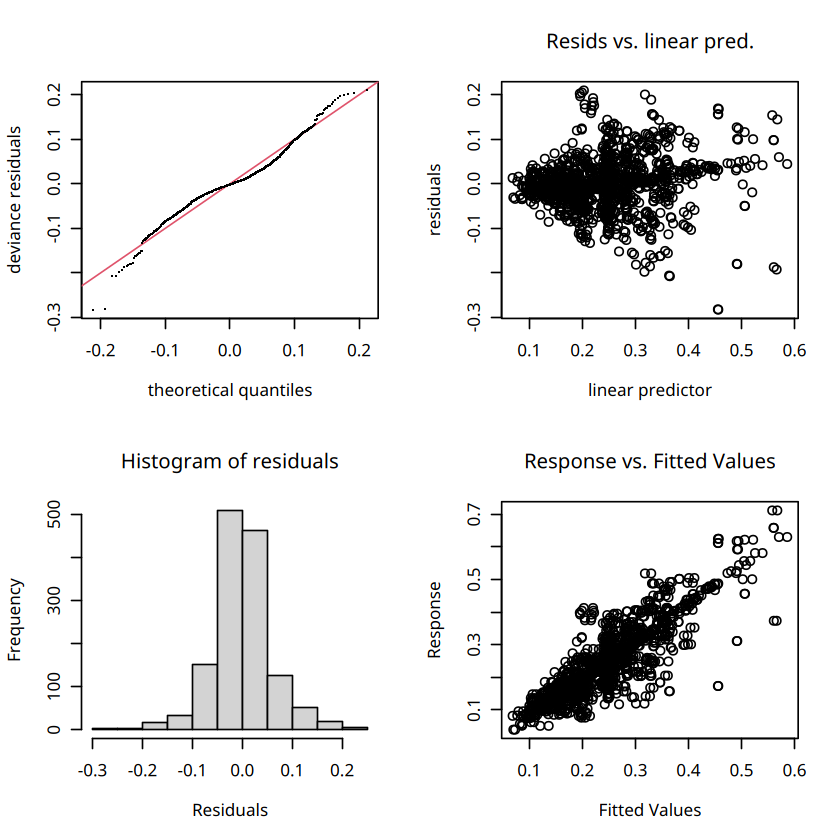


Method: ML   Optimizer: outer newton
full convergence after 5 iterations.
Gradient range [-1.935308e-06,-4.220911e-08]
(score -3390.035 & scale 0.0002780146).
Hessian positive definite, eigenvalue range [0.7825778,709.6726].
Model rank =  275 / 275 

Basis dimension (k) checking results. Low p-value (k-index<1) may
indicate that k is too low, especially if edf is close to k'.

                    k'    edf k-index p-value  
s(SNV_distance)   4.00   3.58    0.95    0.03 *
s(Species)      270.00 229.83      NA      NA  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


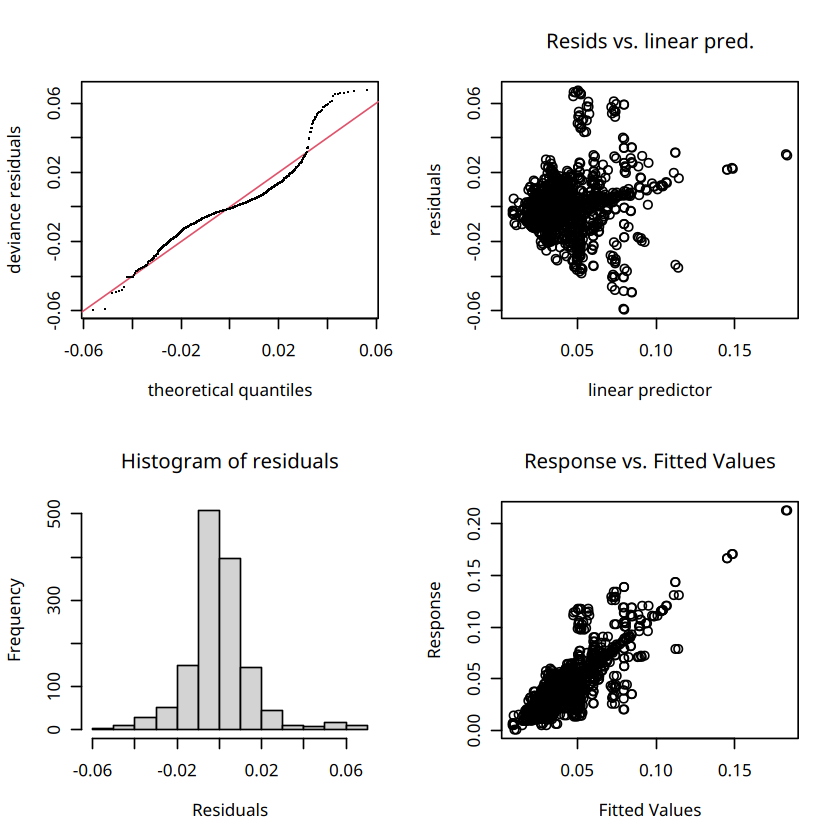

In [77]:
### Somewhat inconclusive whether a GAM fit or quadratic fit captures the relationship
### So we will explore more

# Check the GAM fits to determin if the provided 'k' is too constrained
gam.check(gene_comparison$gam_fit)
gam.check(pfam_comparison$gam_fit)

In [78]:
### Extract GAM smooth
get_gam_smooth_curve = function(gam_fit, data, species_col = "Species") {
    xrange = seq(min(data$SNV_distance), max(data$SNV_distance), length.out = 200)
 
    ## exclude the random-effect smooth so this reflects the
    ## population-average curve, not any specific species
    newdata = data.frame(
        SNV_distance = xrange,
        Species = factor(data[[species_col]][1], levels = levels(data[[species_col]]))
    )
 
    pred = predict(gam_fit, newdata = newdata, se.fit = TRUE,
                    exclude = "s(Species)", newdata.guaranteed = TRUE)
 
    data.frame(
        SNV_distance = xrange,
        fit   = pred$fit,
        lower = pred$fit - 1.96 * pred$se.fit,
        upper = pred$fit + 1.96 * pred$se.fit
    )
}
 
gene_data_factor = gene_data %>% mutate(Species = as.factor(Species))
pfam_data_factor = pfam_data %>% mutate(Species = as.factor(Species))
 
gene_gam_curve = get_gam_smooth_curve(gene_comparison$gam_fit, gene_data_factor) %>%
    mutate(Gene_level = "Gene cluster")
pfam_gam_curve = get_gam_smooth_curve(pfam_comparison$gam_fit, pfam_data_factor) %>%
    mutate(Gene_level = "Pfam family")
 
gam_curves = bind_rows(gene_gam_curve, pfam_gam_curve) %>%
    mutate(Gene_level = factor(Gene_level, levels = c("Gene cluster", "Pfam family")))

In [79]:
### Extract the quadratic fit lmer curve

get_quadratic_curve = function(poly_fit, data) {
    xrange = seq(min(data$SNV_distance), max(data$SNV_distance), length.out = 200)
    newdata = data.frame(SNV_distance = xrange)
    pred = predict(poly_fit, newdata = newdata, re.form = NA)
    data.frame(SNV_distance = xrange, fit = pred)
}
 
gene_quad_curve = get_quadratic_curve(gene_comparison$poly_fit, gene_data) %>%
    mutate(Gene_level = "Gene cluster")
pfam_quad_curve = get_quadratic_curve(pfam_comparison$poly_fit, pfam_data) %>%
    mutate(Gene_level = "Pfam family")
 
quad_curves = bind_rows(gene_quad_curve, pfam_quad_curve) %>%
    mutate(Gene_level = factor(Gene_level, levels = c("Gene cluster", "Pfam family")))

Warning message:
“Removed 6 rows containing missing values or values outside the scale range
(`geom_point()`).”


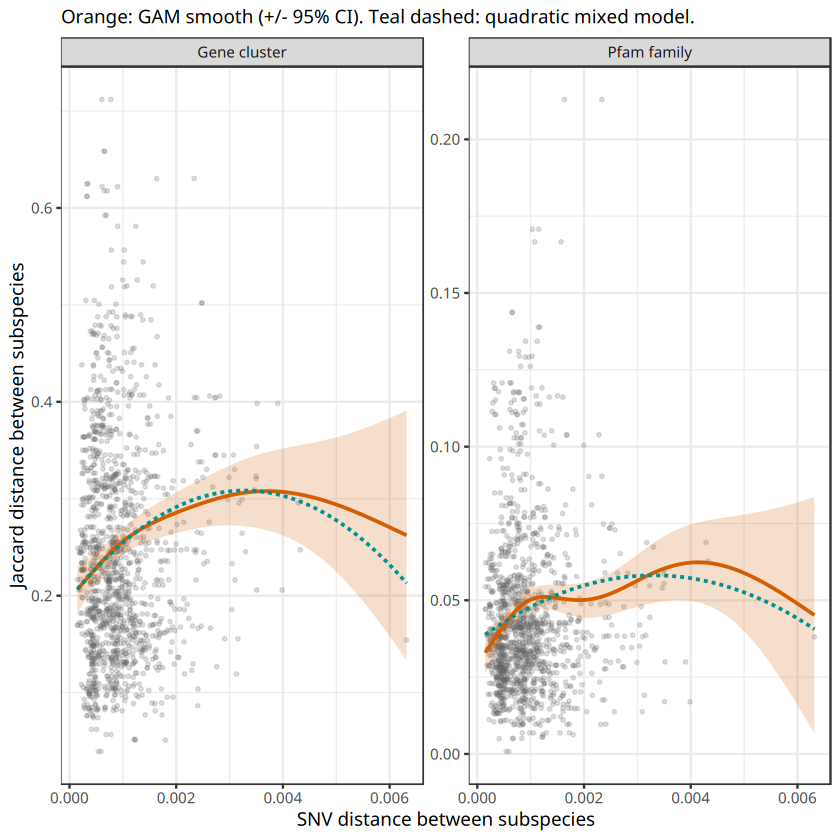

In [82]:
### Visually compare the GAM smooth and lmer quadratic fit curve

pairwise_snv_jaccard_plot_data = pairwise_jaccard %>%
    mutate(Gene_level = factor(Gene_level, levels = c("Gene cluster", "Pfam family")))
 
shape_comparison_plot = ggplot() +
    geom_point(data = pairwise_snv_jaccard_plot_data,
               aes(x = SNV_distance, y = Jaccard_distance),
               alpha = 0.2, size = 0.6, colour = "grey40") +
    geom_ribbon(data = gam_curves, aes(x = SNV_distance, ymin = lower, ymax = upper),
                alpha = 0.2, fill = "#d55e00") +
    geom_line(data = gam_curves, aes(x = SNV_distance, y = fit),
              colour = "#d55e00", linewidth = 0.8) +
    geom_line(data = quad_curves, aes(x = SNV_distance, y = fit),
              colour = "#009292", linewidth = 0.8, linetype = "dashed") +
    facet_wrap(~ Gene_level, scales = "free") +
    theme_bw() +
    labs(
        x = "SNV distance between subspecies",
        y = "Jaccard distance between subspecies",
        subtitle = "Orange: GAM smooth (+/- 95% CI). Teal dashed: quadratic mixed model."
    )
 
shape_comparison_plot

In [83]:
### The result is a highly agreeable shape between both the GAM and the Quadratic linear fit
### However, the decline at the higher end of the SNV distance spectrum may be driven by only a couple of outlier points
### Therefore, let's reassess the fit after removing those outliers

# Refit excluding the top 1% most extreme SNV_distance values per Gene_level
gene_data_trimmed = gene_data %>%
    filter(SNV_distance <= quantile(SNV_distance, 0.99)) %>%
    mutate(Species = as.factor(Species))

pfam_data_trimmed = pfam_data %>%
    filter(SNV_distance <= quantile(SNV_distance, 0.99)) %>%
    mutate(Species = as.factor(Species))

gene_gam_trimmed = mgcv::gam(Jaccard_distance ~ s(SNV_distance, k = 5) + s(Species, bs = "re"),
                              data = gene_data_trimmed, method = "ML")
pfam_gam_trimmed = mgcv::gam(Jaccard_distance ~ s(SNV_distance, k = 5) + s(Species, bs = "re"),
                              data = pfam_data_trimmed, method = "ML")

summary(gene_gam_trimmed)$edf   # compare against 3.74 - much lower would suggest the tail was driving it
summary(pfam_gam_trimmed)$edf

### Re-visualise the curves after removing the high SNV distance outliers
gene_trimmed_curve = get_gam_smooth_curve(gene_gam_trimmed, gene_data_trimmed) %>%
    mutate(Gene_level = "Gene cluster")
pfam_trimmed_curve = get_gam_smooth_curve(pfam_gam_trimmed, pfam_data_trimmed) %>%
    mutate(Gene_level = "Pfam family")

trimmed_curves = bind_rows(gene_trimmed_curve, pfam_trimmed_curve) %>%
    mutate(Gene_level = factor(Gene_level, levels = c("Gene cluster", "Pfam family")),
           fit_type = "Trimmed (top 1% SNV removed)")

full_curves = gam_curves %>%
    mutate(fit_type = "Full data")

curve_comparison = bind_rows(full_curves, trimmed_curves)

snv_jaccard_gam_panel_full_and_capped_model = ggplot() +
    geom_point(data = pairwise_snv_jaccard_plot_data,
               aes(x = SNV_distance, y = Jaccard_distance),
               alpha = 0.15, size = 0.5, colour = "grey50") +
    geom_ribbon(data = curve_comparison, aes(x = SNV_distance, ymin = lower, ymax = upper, fill = fit_type),
                alpha = 0.2) +
    geom_line(data = curve_comparison, aes(x = SNV_distance, y = fit, colour = fit_type), linewidth = 0.8) +
    facet_wrap(~ Gene_level, scales = "free") +
    scale_colour_manual(values = c("Full data" = "#d55e00", "Trimmed (top 1% SNV removed)" = "#0072b2")) +
    scale_fill_manual(values = c("Full data" = "#d55e00", "Trimmed (top 1% SNV removed)" = "#0072b2")) +
    theme_bw() +
    theme(
        strip.background = element_rect(fill = "white", colour = "black"),
        strip.text = element_text(size = 12),
        axis.text = element_text(size = 10),
        axis.title = element_text(size = 12),
        plot.caption = element_text(size = 8, colour = "grey40", hjust = 0)
    ) +
    labs(x = "SNV distance between subspecies", y = "Jaccard distance between subspecies", colour = NULL, fill = NULL) +
    theme(legend.position = "bottom")


# Export figures
ggsave(paste0(output_figures,"across_species/species_selected.subspecies.gene_comp_jacc_vs_snv_dist_scatter_full_and_capped_model.pdf"), plot = snv_jaccard_gam_panel_full_and_capped_model, device = "pdf", height = 5, width = 8, units = "in")
ggsave(paste0(output_figures,"across_species/species_selected.subspecies.gene_comp_jacc_vs_snv_dist_scatter_full_and_capped_model.png"), plot = snv_jaccard_gam_panel_full_and_capped_model, device = "png", height = 5, width = 8, units = "in")

[1]   3.168838 237.048269

[1]   3.243423 228.650840

Warning message:
“Removed 6 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 6 rows containing missing values or values outside the scale range
(`geom_point()`).”


In [85]:
### This shows that the few outlier high SNV distances were pulling the fit down at the end, pointing towards a quadratic fit.
### However, given the very few data points in this range, this final region of SNV distances can not be accurately modeled.
### Therefore, we will proceed with a GAM fit encompassing the 99th percentile of SNV distances - which shows a plateau at higher SNV distances
### for gene cluster distances and a slight increase in pfam distances

### Extract only top 99th percentile and rebuild the distance table
gene_cutoff = quantile(gene_data$SNV_distance, 0.99)
pfam_cutoff = quantile(pfam_data$SNV_distance, 0.99)
 
pairwise_snv_jaccard_plotted = pairwise_jaccard %>%
    mutate(Gene_level = factor(Gene_level, levels = c("Gene cluster", "Pfam family"))) %>%
    filter(
        (Gene_level == "Gene cluster" & SNV_distance <= gene_cutoff) |
        (Gene_level == "Pfam family"  & SNV_distance <= pfam_cutoff)
    )

### Extract trimmed GAM's smooth curve
get_gam_smooth_curve = function(gam_fit, data, species_col = "Species") {
    xrange = seq(min(data$SNV_distance), max(data$SNV_distance), length.out = 200)
 
    newdata = data.frame(
        SNV_distance = xrange,
        Species = factor(data[[species_col]][1], levels = levels(data[[species_col]]))
    )
 
    pred = predict(gam_fit, newdata = newdata, se.fit = TRUE,
                    exclude = "s(Species)", newdata.guaranteed = TRUE)
 
    data.frame(
        SNV_distance = xrange,
        fit   = pred$fit,
        lower = pred$fit - 1.96 * pred$se.fit,
        upper = pred$fit + 1.96 * pred$se.fit
    )
}
 
gene_trimmed_curve = get_gam_smooth_curve(gene_gam_trimmed, gene_data_trimmed) %>%
    mutate(Gene_level = "Gene cluster")
pfam_trimmed_curve = get_gam_smooth_curve(pfam_gam_trimmed, pfam_data_trimmed) %>%
    mutate(Gene_level = "Pfam family")
 
trimmed_curves = bind_rows(gene_trimmed_curve, pfam_trimmed_curve) %>%
    mutate(Gene_level = factor(Gene_level, levels = c("Gene cluster", "Pfam family")))

### Calculate marginal and conditional (species-influenced) R2 for the GAM, and the smooth-term significance
r2_gam_manual = function(gam_fit, data) {
    ## Variance explained by the smooth term alone (Species excluded)
    pred_fixed = predict(gam_fit, newdata = data, exclude = "s(Species)")
    var_fixed  = var(pred_fixed)
 
    ## Species random-intercept variance component. gam.vcomp() row
    ## naming can vary slightly by mgcv version - print(vc) once to
    ## confirm the exact row name if this grep doesn't match.
    vc = gam.vcomp(gam_fit)
    species_row = grep("Species", rownames(vc), value = TRUE)[1]
    var_random  = vc[species_row, "std.dev"]^2
 
    ## Residual variance (Gaussian family)
    var_resid = gam_fit$sig2
 
    total_var = var_fixed + var_random + var_resid
 
    data.frame(
        marginal_r2    = var_fixed / total_var,
        conditional_r2 = (var_fixed + var_random) / total_var
    )
}
 
get_gam_annotation = function(gam_fit, data, label) {
    s = summary(gam_fit)
    r2s = r2_gam_manual(gam_fit, data)
 
    data.frame(
        Gene_level     = label,
        marginal_r2    = r2s$marginal_r2,
        conditional_r2 = r2s$conditional_r2,
        edf            = s$s.table["s(SNV_distance)", "edf"],
        p.value        = s$s.table["s(SNV_distance)", "p-value"]
    )
}
 
panel_annotations = bind_rows(
    get_gam_annotation(gene_gam_trimmed, gene_data_trimmed, "Gene cluster"),
    get_gam_annotation(pfam_gam_trimmed, pfam_data_trimmed, "Pfam family")
) %>%
    mutate(
        Gene_level = factor(Gene_level, levels = c("Gene cluster", "Pfam family")),
        p_label = ifelse(p.value < 2.2e-16, "p < 2.2e-16", paste0("p = ", signif(p.value, 3))),
        label = paste0(
            "Marginal R\u00B2 = ", round(marginal_r2, 3),
            "\nConditional R\u00B2 = ", round(conditional_r2, 3),
            "\n  ", p_label
        )
    )


Standard deviations and 0.95 confidence intervals:

                     std.dev        lower        upper
s(SNV_distance) 2.545236e+03 594.03657458 1.090544e+04
s(Species)      1.055029e-01   0.09581999 1.161642e-01
scale           6.244864e-02   0.05987139 6.513684e-02

Rank: 3/3

Standard deviations and 0.95 confidence intervals:

                     std.dev        lower        upper
s(SNV_distance) 724.47992607 239.12477512 2.194968e+03
s(Species)        0.02456746   0.02220176 2.718523e-02
scale             0.01672262   0.01603115 1.744391e-02

Rank: 3/3


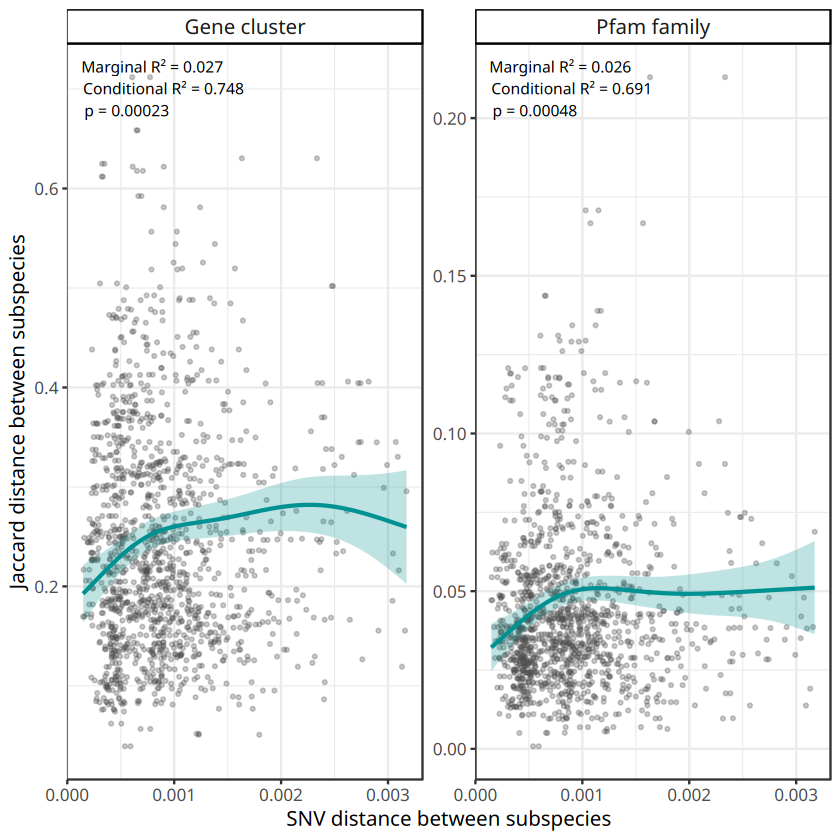

In [86]:
### Visualise the GAM fits
snv_jaccard_gam_panel = ggplot() +
    geom_point(
        data = pairwise_snv_jaccard_plotted,
        aes(x = SNV_distance, y = Jaccard_distance),
        alpha = 0.3, size = 0.7, colour = "grey30"
    ) +
    geom_ribbon(
        data = trimmed_curves,
        aes(x = SNV_distance, ymin = lower, ymax = upper),
        alpha = 0.25, fill = "#009292"
    ) +
    geom_line(
        data = trimmed_curves,
        aes(x = SNV_distance, y = fit),
        colour = "#009292", linewidth = 0.9
    ) +
    geom_text(
        data = panel_annotations,
        aes(x = -Inf, y = Inf, label = label),
        hjust = -0.1, vjust = 1.3, size = 3.2, inherit.aes = FALSE
    ) +
    facet_wrap(~ Gene_level, scales = "free") +
    theme_bw() +
    labs(
        x = "SNV distance between subspecies",
        y = "Jaccard distance between subspecies",
    ) +
    theme(
        strip.background = element_rect(fill = "white", colour = "black"),
        strip.text = element_text(size = 12),
        axis.text = element_text(size = 10),
        axis.title = element_text(size = 12),
        plot.caption = element_text(size = 8, colour = "grey40", hjust = 0)
    )
 
snv_jaccard_gam_panel

# Export figures
ggsave(paste0(output_figures,"across_species/species_selected.subspecies.gene_comp_jacc_vs_snv_dist_scatter.pdf"), plot = snv_jaccard_gam_panel, device = "pdf", height = 5, width = 8, units = "in")
ggsave(paste0(output_figures,"across_species/species_selected.subspecies.gene_comp_jacc_vs_snv_dist_scatter.png"), plot = snv_jaccard_gam_panel, device = "png", height = 5, width = 8, units = "in")

## Species-mean normalised comparison

In [88]:
species_population_counts = subspecies_gene_and_pfam_diff_dist %>%
    distinct(Species, Subspecies_one) %>%
    rename(Subspecies = Subspecies_one) %>%
    bind_rows(
        subspecies_gene_and_pfam_diff_dist %>%
            distinct(Species, Subspecies_two) %>%
            rename(Subspecies = Subspecies_two)
    ) %>%
    distinct(Species, Subspecies) %>%
    count(Species, name = "n_subspecies")

species_to_keep = species_population_counts %>% filter(n_subspecies >= 3) %>% pull(Species)

subspecies_gene_and_pfam_diff_dist_mod = subspecies_gene_and_pfam_diff_dist %>%
    filter(Species %in% species_to_keep)
species_subspsnv_diff_dist_mod = species_subspsnv_diff_dist %>%
    filter(Species %in% species_to_keep)

species_mean_snv = species_subspsnv_diff_dist_mod %>%
    aggregate(SNV_distance ~ Species, data = ., FUN = mean) %>%
    rename(mean_species_snv = SNV_distance)
 
species_subspsnv_diff_dist_mod_norm = species_subspsnv_diff_dist_mod %>%
    left_join(species_mean_snv, by = "Species") %>%
    mutate(normalised_snv_distance = (SNV_distance / mean_species_snv))

species_mean_jaccard = subspecies_gene_and_pfam_diff_dist_mod %>%
    aggregate(Jaccard_distance ~ Species + Gene_level, data = ., FUN = mean) %>%
    rename(mean_species_jaccard = Jaccard_distance)
 
subspecies_gene_and_pfam_diff_dist_mod_norm = subspecies_gene_and_pfam_diff_dist_mod %>%
    left_join(species_mean_jaccard, by = c("Species", "Gene_level")) %>%
    mutate(normalised_jaccard = (Jaccard_distance / mean_species_jaccard))

pairwise_jaccard_norm = subspecies_gene_and_pfam_diff_dist_mod_norm %>%
    left_join(
        species_subspsnv_diff_dist_mod_norm %>%
            select(Species, Subspecies_one, Subspecies_two, normalised_snv_distance),
        by = c("Species", "Subspecies_one", "Subspecies_two")
    )
 
gene_data_norm = pairwise_jaccard_norm %>%
    filter(Gene_level == "Gene cluster", !is.na(normalised_snv_distance), !is.na(normalised_jaccard))
pfam_data_norm = pairwise_jaccard_norm %>%
    filter(Gene_level == "Pfam family", !is.na(normalised_snv_distance), !is.na(normalised_jaccard))

`geom_smooth()` using formula = 'y ~ x'
Saving 6.67 x 6.67 in image
Saving 6.67 x 6.67 in image


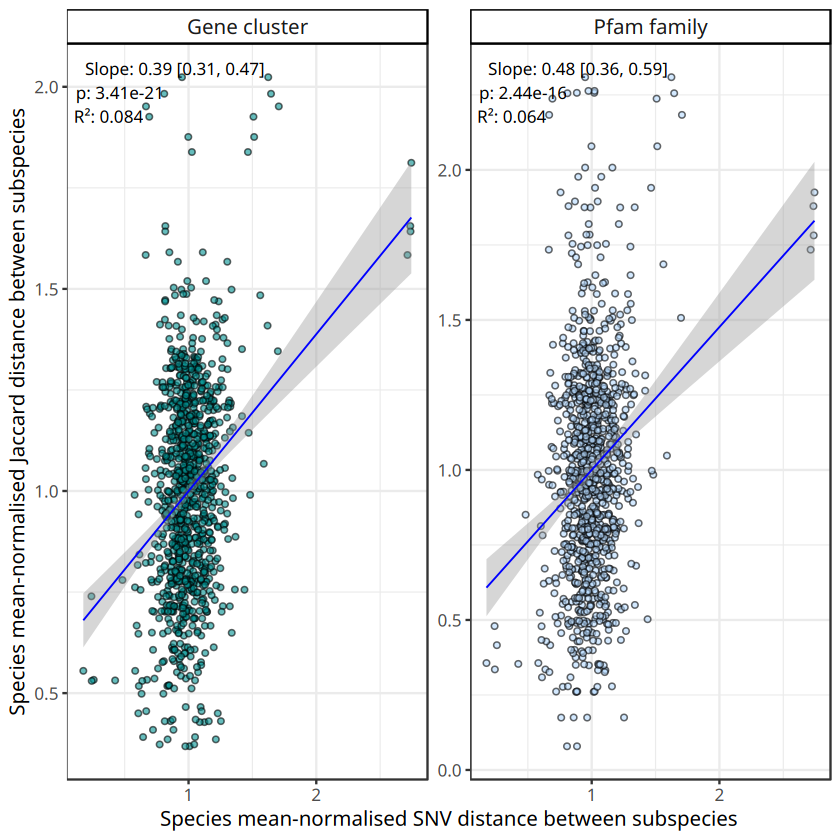

In [89]:
### Fit and visualise
normalised_regression_df = pairwise_jaccard_norm %>%
    filter(!is.na(normalised_snv_distance), !is.na(normalised_jaccard)) %>%
    group_by(Gene_level) %>%
    nest() %>%
    mutate(
        lm_fit     = map(data, ~ lm(normalised_jaccard ~ normalised_snv_distance, data = .x)),
        tidy_fit   = map(lm_fit, ~ tidy(.x, conf.int = TRUE)),
        glance_fit = map(lm_fit, glance)
    ) %>%
    unnest(c(tidy_fit, glance_fit), names_sep = "_") %>%
    filter(tidy_fit_term == "normalised_snv_distance") %>%
    select(Gene_level, estimate = tidy_fit_estimate, conf.low = tidy_fit_conf.low,
           conf.high = tidy_fit_conf.high, p.value = tidy_fit_p.value,
           r.squared = glance_fit_r.squared) %>%
    mutate(Gene_level = factor(Gene_level, levels = c("Gene cluster", "Pfam family")))
 
normalised_annotations = normalised_regression_df %>%
    mutate(label = paste0(
        "Slope: ", round(estimate, 2), " [", round(conf.low, 2), ", ", round(conf.high, 2), "]",
        "\np: ", signif(p.value, 3),
        "\nR\u00B2: ", signif(r.squared, 2)
    ))
 
pairwise_jaccard_norm_plot_data = pairwise_jaccard_norm %>%
    filter(!is.na(normalised_snv_distance), !is.na(normalised_jaccard)) %>%
    mutate(Gene_level = factor(Gene_level, levels = c("Gene cluster", "Pfam family")))
 
species_mean_normalised_scatter = ggplot(
    pairwise_jaccard_norm_plot_data,
    aes(x = normalised_snv_distance, y = normalised_jaccard)
) +
    geom_point(aes(fill = Gene_level), colour = "black", shape = 21, alpha = 0.6, size = 1.2, show.legend = FALSE) +
    stat_smooth(method = "lm", se = TRUE, colour = "blue", linewidth = 0.4) +
    geom_text(
        data = normalised_annotations,
        aes(x = -Inf, y = Inf, label = label),
        hjust = -0.1, vjust = 1.3, size = 3.5, inherit.aes = FALSE
    ) +
    facet_wrap(~ Gene_level, scales = "free") +
    scale_fill_manual(values = c("Gene cluster" = "#009292", "Pfam family" = "#b6dbff")) +
    theme_bw() +
    labs(
        x = "Species mean-normalised SNV distance between subspecies",
        y = "Species mean-normalised Jaccard distance between subspecies"
    ) +
    theme(
        strip.background = element_rect(fill = "white", colour = "black"),
        strip.text = element_text(size = 12),
        axis.text = element_text(size = 10),
        axis.title = element_text(size = 12)
    )
 
species_mean_normalised_scatter

# Export figures
ggsave(paste0(output_figures,"across_species/species_selected.subspecies.gene_comp_jacc_vs_snv_dist_scatter-spec_mean_normalised.pdf"), plot = snv_jaccard_gam_panel, device = "pdf", dpi = 300, units = "in")
ggsave(paste0(output_figures,"across_species/species_selected.subspecies.gene_comp_jacc_vs_snv_dist_scatter-spec_mean_normalised.png"), plot = snv_jaccard_gam_panel, device = "png", dpi = 300, units = "in")

# Combine figures

In [92]:
#####

### Combine figures

species_subsp_gene_comp_diversification_figure <- snv_jaccard_gam_panel/(subspecies_gene_clust_pfam_jaccard_density|species_subsp_gene_comp_counts_violin)

# Export figures
ggsave(paste0(output_figures,"species_selected.subspecies.jaccard_vs_snv_and_gene_comp_diversity_figure.pdf"), plot = species_subsp_gene_comp_diversification_figure, device = "pdf", width=8, height=8, units = "in")
ggsave(paste0(output_figures,"species_selected.subspecies.jaccard_vs_snv_and_gene_comp_diversity_figure.png"), plot = species_subsp_gene_comp_diversification_figure, device = "png", width=8, height=8, units = "in")


# Assess species and population pNpS variations

## Load and reformat data

In [ ]:
#####

### Assess species and population pNpS values in relation to gene composition

#####
species_pnps = fread(paste0(input_dir,"species_selected.pnps.tsv.gz"), sep = "\t", header=T)
sp_core_gene_list = fread(file=paste0(output_tables,"across_species/species_selected.species_core_gene_list.tsv"), sep="\t", header=T)
sp_all_gene_catalog = fread(paste0(input_dir,"species_selected.gene_catalog.tsv"), sep = "\t", header=T)


In [37]:
### Filter pNpS to only include:
### 1) samples passing threshold 
### 2) species core gene clusters

samp_to_subsp = sp_all_gene_catalog %>%
    select(Sample,Subspecies,Species) %>%
    distinct()

sp_subsp_count <- sp_all_gene_catalog %>%
    group_by(Species) %>%
    summarise(n_pops_total = n_distinct(Subspecies),
    .groups="drop")

sp_genes_pnps_filt = species_pnps %>%
    filter(., Species %in% samp_to_subsp$Species & Sample %in% samp_to_subsp$Sample) %>%
    select(Sample,Species,Gene_catalog_rep,pNpS) %>%
    left_join(samp_to_subsp, by=c("Species","Sample")) %>%
    filter(is.finite(pNpS), !is.na(pNpS)) %>%
    distinct()
    
sp_core_genes_pnps_filt = sp_genes_pnps_filt %>%
    filter(., Gene_catalog_rep %in% sp_core_gene_list$Gene_catalog_rep) %>%
    distinct()

In [38]:
rm(sp_all_gene_catalog)
rm(species_pnps)

## Generate summary statistics on species

In [39]:
species_subsp_inventory <- sp_core_genes_pnps_filt %>%
  group_by(Species) %>%
  summarise(
    n_subspecies = n_distinct(Subspecies),
    n_genes = n_distinct(Gene_catalog_rep),
    n_samples = n_distinct(Sample),
    n_obs = n(),
    .groups = "drop"
  )

In [40]:
head(species_subsp_inventory)

Species,n_subspecies,n_genes,n_samples,n_obs
<chr>,<int>,<int>,<int>,<int>
1064_1,5,559,16,1600
1074_1,2,2657,76,82078
108_1,2,780,9,1276
1126_2,2,2958,28,29782
1127_1,3,2907,26,20733
1132_1,2,2565,41,42029


## Model variance in pNpS values

In [41]:
### Variance partitioning model to determine whether variation in pNpS values are shaped by: species, subspecies, genes, sample-to-sample noise
vp_mod_tw <- glmmTMB(
  pNpS ~ 1 + (1 | Species/Subspecies) + (1 | Gene_catalog_rep),
  family = tweedie(link = "log"),
  data = sp_core_genes_pnps_filt
)

saveRDS(vp_mod_tw, file=paste0(output_tables,"across_species/species_selected.core_gene_pnps_glmm_model.rds"))

summary(vp_mod_tw)


 Family: tweedie  ( log )
Formula:          pNpS ~ 1 + (1 | Species/Subspecies) + (1 | Gene_catalog_rep)
Data: sp_core_genes_pnps_filt

      AIC       BIC    logLik  deviance  df.resid 
-15339772 -15339690   7669892 -15339784   6230918 

Random effects:

Conditional model:
 Groups             Name        Variance Std.Dev.
 Subspecies:Species (Intercept) 0.0163   0.1277  
 Species            (Intercept) 0.1384   0.3721  
 Gene_catalog_rep   (Intercept) 1.1595   1.0768  
Number of obs: 6230924, groups:  
Subspecies:Species, 680; Species, 270; Gene_catalog_rep, 348927

Dispersion parameter for tweedie family (): 0.185 

Conditional model:
            Estimate Std. Error z value Pr(>|z|)    
(Intercept) -2.45067    0.02336  -104.9   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

In [ ]:
# Check the fit is good
plot(fitted(vp_mod_tw), residuals(vp_mod_tw, type = "pearson"))
abline(h = 0, col = "red")

ERROR: Error in library(DHARMa): there is no package called ‘DHARMa’


In [ ]:
icc(vp_mod_tw)          # per-grouping-factor ICC, if supported for tweedie
r2_nakagawa(vp_mod_tw)  # marginal/conditional R2, if supported

In [ ]:
vc_tw <- as.data.frame(VarCorr(vp_mod_tw)) %>%
  filter(component == "cond") %>%
  mutate(pct_variance = vcov / sum(vcov) * 100) %>%
  select(grp, vcov, pct_variance)
  
print(vc_tw)

fwrite(vc_tw, file=paste0(output_tables,"across_species/species_selected.core_gene_pnps_variance_partitioning.tsv"), sep="\t")

ERROR: [1m[33mError[39m in `mutate()`:[22m
[1m[22m[36mℹ[39m In argument: `pct_variance = vcov/sum(vcov) * 100`.
[1mCaused by error in `sum()`:[22m
[33m![39m invalid 'type' (closure) of argument


## Compare pNpS values across species

In [52]:
#####
# Assess the variation in the pNpS at species level
#####

### Collapse sample-level observations to one value per gene
sp_core_gene_level <- sp_core_genes_pnps_filt %>%
  filter(!is.na(pNpS)) %>%
  group_by(Species, Gene_catalog_rep) %>%
  summarise(
    n_obs = n(),
    mean_pNpS_gene = mean(pNpS, na.rm = TRUE),
    median_pNpS_gene = median(pNpS, na.rm = TRUE),
    .groups = "drop"
  )

In [53]:
#####
# Test whether there are significant differences in the distribution of pNpS values across species and subspecies
#####

kt_species <- kruskal.test(mean_pNpS_gene ~ Species, data = sp_core_gene_level)
es_species <- sp_core_gene_level %>% kruskal_effsize(mean_pNpS_gene ~ Species) %>% pull(effsize)

In [54]:
kt_species
es_species


	Kruskal-Wallis rank sum test

data:  mean_pNpS_gene by Species
Kruskal-Wallis chi-squared = 41006, df = 269, p-value < 2.2e-16


Kruskal-Wallis chi-squared 
                 0.1148963

In [55]:
### Summarise pNpS values at the species level
sp_core_pnps_summary <- sp_core_gene_level %>%
  group_by(Species) %>%
  summarise(
    n_genes = n(),
    mean_pNpS = mean(mean_pNpS_gene, na.rm = TRUE),
    median_pNpS = median(mean_pNpS_gene, na.rm = TRUE),
    sd_pNpS = sd(mean_pNpS_gene, na.rm = TRUE),
    q25 = quantile(mean_pNpS_gene, 0.25, na.rm = TRUE),
    q75 = quantile(mean_pNpS_gene, 0.75, na.rm = TRUE),
    prop_gt1 = mean(mean_pNpS_gene > 1, na.rm = TRUE)
  ) %>%
  arrange(desc(median_pNpS)) %>%
  filter(n_genes > 100)

## Compare pNpS values across subspecies

In [11]:
#####
# How does pNpS differ across subspecies within the same species?
#####

pop_tests <- sp_core_genes_pnps_filt %>%
  filter(!is.na(pNpS), !is.na(Subspecies)) %>%   # drop rows with missing pNpS OR missing
  group_by(Species) %>%                            # population assignment - both otherwise
  group_modify(~ {                                 # inflate apparent group counts
    n_pop <- n_distinct(.x$Subspecies)
    if (n_pop < 2) {
      return(tibble(n_subspecies = n_pop, chisq = NA, p.value = NA, epsilon_sq = NA))
    }
    kt <- tryCatch(kruskal.test(pNpS ~ Subspecies, data = .x), error = function(e) NULL)
    if (is.null(kt)) {
      return(tibble(n_subspecies = n_pop, chisq = NA, p.value = NA, epsilon_sq = NA))
    }
    es <- tryCatch(
      .x %>% kruskal_effsize(pNpS ~ Subspecies) %>% pull(effsize),
      error = function(e) NA_real_
    )
    tibble(n_subspecies = n_pop, chisq = kt$statistic, p.value = kt$p.value, epsilon_sq = es)
  }) %>%
  ungroup() %>%
  mutate(p.adj = p.adjust(p.value, method = "BH", n = sum(!is.na(p.value)))) %>%
  left_join(species_subsp_inventory %>% select(Species, n_genes, n_obs), by = "Species") %>%
  mutate(reliable = n_genes >= 100 & n_obs >= 50)  

fwrite(pop_tests, file=paste0(output_tables,"across_species/species_selected.subspecies.pnps_kruskal_test_result.tsv"), sep="\t")


In [12]:
pop_tests %>%
    filter(., reliable == TRUE) %>%
    dim()

[1] 267   9

In [15]:
pop_tests %>%
    filter(., p.adj < 0.05 & reliable == TRUE) %>%
    dim()

[1] 200   9

## Assessing selective regimes across species core genes

In [62]:
#####
# What proportion of core genes show diversifying selection (pNpS > 1),
# and is this signal species-wide or population-specific?
#####

species_core_genes <- sp_core_gene_list %>%
  distinct(Species, Gene_catalog_rep)

# Gene x Subspecies level: aggregate pNpS across samples within a population
gene_pop_status <- sp_core_genes_pnps_filt %>%
  filter(!is.na(pNpS), !is.na(Subspecies)) %>%
  group_by(Species, Gene_catalog_rep, Subspecies) %>%
  summarise(
    n_samples = n(),
    mean_pNpS = mean(pNpS, na.rm = TRUE),
    median_pNpS = median(pNpS, na.rm = TRUE),
    diversifying = mean_pNpS > 1,
    .groups = "drop"
  ) %>%
  mutate(reliable_gp = n_samples >= 3)

fwrite(gene_pop_status, file = paste0(output_tables, "across_species/species_selected.subspecies.gene_pnps_status.tsv"), sep = "\t")



In [63]:
#####
# Per-gene diversifying counts, restricted to reliable subspecies only for
# the COUNT itself, but compared against the species' TOTAL subspecies
# count (n_pops_total) per your point 1 - not just the reliable subset.
#####
gene_diversifying_counts <- gene_pop_status %>%
  filter(reliable_gp) %>%
  group_by(Species, Gene_catalog_rep) %>%
  summarise(
    n_reliable_pops    = n_distinct(Subspecies),
    n_pop_diversifying = sum(diversifying),
    .groups = "drop"
  )

### gene_summary now starts from ALL core genes (species_core_genes), not
### just genes that happened to survive the reliability filter - anything
### with zero reliable subspecies is explicitly flagged rather than absent.
gene_summary <- species_core_genes %>%
  left_join(gene_diversifying_counts, by = c("Species", "Gene_catalog_rep")) %>%
  left_join(sp_subsp_count, by = "Species") %>%
  mutate(
    n_reliable_pops    = replace_na(n_reliable_pops, 0L),
    n_pop_diversifying = replace_na(n_pop_diversifying, 0L),
    category = case_when(
      n_reliable_pops == 0               ~ "Insufficient_data",
      n_pop_diversifying == 0            ~ "none",
      n_pop_diversifying == n_pops_total ~ "Species_wide",
      TRUE                                ~ "Subspecies_specific"
    )
  )

fwrite(gene_summary, file = paste0(output_tables, "across_species/species_selected.genes_pnps_divers.tsv"), sep = "\t")

In [64]:
#####
# Fold-change eligibility and permutation test - unchanged logic, just
# sourced from gene_diversifying_counts rather than re-deriving n_reliable_pops
#####
fc_eligible_genes <- gene_diversifying_counts %>%
  filter(n_reliable_pops >= 2) %>%
  select(Species, Gene_catalog_rep, n_reliable_pops)

reliable_pops <- gene_pop_status %>%
  filter(reliable_gp) %>%
  select(Species, Gene_catalog_rep, Subspecies)

fc_input_data <- sp_core_genes_pnps_filt %>%
  inner_join(fc_eligible_genes, by = c("Species", "Gene_catalog_rep")) %>%
  inner_join(reliable_pops, by = c("Species", "Gene_catalog_rep", "Subspecies")) %>%
  select(Species, Gene_catalog_rep, Subspecies, Sample, pNpS)

rm(sp_core_genes_pnps_filt)

In [ ]:
# Per-species function: computes fold-change permutation test for
# ALL genes within one species, using data.table's native grouped `by=`

compute_fc_permtest_species <- function(species_dt, n_perm = 500, seed = 1) {
  set.seed(seed)

  species_dt[, {
    pop_int <- as.integer(factor(Subspecies))
    pnps    <- pNpS
    n       <- length(pnps)
    n_pops  <- length(unique(pop_int))

    if (n < 2 || n_pops < 2) {
      list(obs_fc = NA_real_, p_perm = NA_real_, n_samples = n, n_pops = n_pops)
    } else {
      obs_n   <- rowsum(rep(1, n), pop_int)
      obs_sum <- rowsum(pnps, pop_int)
      obs_means <- obs_sum / obs_n
      obs_fc <- max(obs_means) / min(obs_means)

      # index-based permutation (avoids sample()'s length-1 ambiguity bug)
      perm_mat <- replicate(n_perm, pop_int[sample.int(n)])
      perm_fc <- apply(perm_mat, 2, function(p) {
        s <- rowsum(pnps, p)
        m <- s / obs_n
        max(m) / min(m)
      })
      p_perm <- (1 + sum(perm_fc >= obs_fc)) / (n_perm + 1)

      list(obs_fc = obs_fc, p_perm = p_perm, n_samples = n, n_pops = n_pops)
    }
  }, by = .(Species, Gene_catalog_rep)]
}

In [ ]:
# Outer parallel dispatch: one task per SPECIES (~270), not per gene
n_cores <- 8
plan(multicore, workers = n_cores)   # <-- only this line changes

setDT(fc_input_data)
species_chunks <- split(fc_input_data, by = "Species")

results_list <- future_lapply(
  species_chunks,
  function(species_dt) {
    compute_fc_permtest_species(species_dt, n_perm = 500, seed = 1)
  },
  future.seed = TRUE,
  future.packages = "data.table"
)

fc_results <- rbindlist(results_list)
fc_results[, p_adj := p.adjust(p_perm, method = "BH")]

fwrite(fc_results, file = paste0(output_tables, "across_species/species_selected.genes_pnps_fold_change_permutation_test.tsv"), sep = "\t")

In [31]:
fc_results = fread(file = paste0(output_tables, "across_species/species_selected.genes_pnps_fold_change_permutation_test.tsv"), sep = "\t")
gene_summary = fread(file = paste0(output_tables, "across_species/species_selected.genes_pnps_divers.tsv"), sep = "\t")

ERROR: Error in fread(file = paste0(output_tables, "across_species/species_selected.genes_pnps_fold_change_permutation_test.tsv"), : File '/nfs/nas22/fs2202/biol_micro_sunagawa/Projects/EAN/OMDV2_POPGEN_EAN/scratch/processed/final/output_tables/across_species/species_selected.genes_pnps_fold_change_permutation_test.tsv' does not exist or is non-readable. getwd()=='/nfs/nas22/fs2202/biol_micro_sunagawa/Projects/EAN/OMDV2_POPGEN_EAN/code/scripts/final'


In [71]:
#####
# Combine both signals - built on the FULL core-gene universe again, so
# genes never eligible for the fold-change test (fc_results never saw
# them) are explicitly "not significant" rather than absent.
#####
fc_results_flagged <- fc_results %>%
  mutate(significant_fold_shift = !is.na(p_adj) & p_adj < 0.05) %>%
  select(Species, Gene_catalog_rep, obs_fc, p_perm, p_adj, significant_fold_shift)

gene_combined_class <- species_core_genes %>%
  left_join(gene_summary %>% select(Species, Gene_catalog_rep, category), by = c("Species", "Gene_catalog_rep")) %>%
  left_join(fc_results_flagged, by = c("Species", "Gene_catalog_rep")) %>%
  mutate(
    significant_fold_shift = replace_na(significant_fold_shift, FALSE),
    diversifying = category %in% c("Species_wide", "Subspecies_specific"),
    combined_class = case_when(
      diversifying & significant_fold_shift  ~ "Both",
      diversifying & !significant_fold_shift ~ "Diversifying selection only",
      !diversifying & significant_fold_shift ~ "Fold-shift only",
      TRUE ~ "Neither"
    )
  )

fwrite(gene_combined_class, file = paste0(output_tables, "across_species/species_selected.genes_combined_selection_class.tsv"), sep = "\t")


In [73]:
overall_gene_class_summary <- gene_combined_class %>%
  count(category, significant_fold_shift) %>%
  group_by(category) %>%
  mutate(prop_within_category = n / sum(n)) %>%
  ungroup()

print(overall_gene_class_summary)

fold_shift_summary <- gene_combined_class %>%
  summarise(
    n_total_core_genes       = n(),
    n_significant_fold_shift = sum(significant_fold_shift, na.rm = TRUE),
    n_fold_shift_and_none    = sum(significant_fold_shift & category == "none", na.rm = TRUE)
  )

print(fold_shift_summary)

# A tibble: 7 × 4
  category            significant_fold_shift      n prop_within_category
  <chr>               <lgl>                   <int>                <dbl>
1 Insufficient_data   FALSE                  281901               1     
2 Species_wide        FALSE                     374               0.926 
3 Species_wide        TRUE                       30               0.0743
4 Subspecies_specific FALSE                    3329               0.851 
5 Subspecies_specific TRUE                      584               0.149 
6 none                FALSE                  278219               0.922 
7 none                TRUE                    23479               0.0778
  n_total_core_genes n_significant_fold_shift n_fold_shift_and_none
1             587916                    24093                 23479


In [ ]:
#####
# Build full species to gene selection table
#####

species_selection_summary <- gene_combined_class %>%
  group_by(Species) %>%
  summarise(
    n_core_genes                = n(),
    prop_diversifying           = mean(diversifying),
    prop_none                   = mean(category == "none"),
    prop_species_wide           = mean(category == "Species_wide"),
    prop_subspecies_specific    = mean(category == "Subspecies_specific"),
    prop_insufficient_data      = mean(category == "Insufficient_data"),
    prop_significant_foldshift  = mean(significant_fold_shift),
    .groups = "drop"
  ) %>%
  left_join(sp_subsp_count, by = "Species") %>%
  rename(n_subspecies = n_pops_total) %>%
  select(Species, n_subspecies, n_core_genes,
         prop_diversifying, prop_none, prop_species_wide, prop_subspecies_specific, prop_insufficient_data,
         prop_significant_foldshift)

fwrite(species_selection_summary, file = paste0(output_tables, "across_species/species_selected.genes_complete_selection_regime_info.tsv"), sep = "\t")

# Filter to only retain those with >100 core genes exhibiting selective pressure signal
species_selection_summary_filt <- species_selection_summary %>%
  filter(n_core_genes > 100)

In [ ]:
#####
# Retrieve summary numbers for results section
#####

### Overall diversifying-selection numbers (headline n and %)
n_total_core_genes <- nrow(gene_combined_class)
n_diversifying     <- sum(gene_combined_class$diversifying)
pct_diversifying   <- n_diversifying / n_total_core_genes * 100

### Of those diversifying genes, how many were NOT species-wide
### (i.e. subspecies-specific or shared by only some subspecies)?
pct_diversifying_not_species_wide <- gene_combined_class %>%
  filter(diversifying) %>%
  summarise(pct = mean(category == "Subspecies_specific") * 100) %>%
  pull(pct)

### Fold-shift numbers (same "all core genes" denominator convention)
n_significant_fold_shift   <- sum(gene_combined_class$significant_fold_shift)
pct_significant_fold_shift <- n_significant_fold_shift / n_total_core_genes * 100

### Range across species for the diversifying-selection proportion
range_prop_diversifying <- species_selection_summary_filt %>%
  summarise(min_pct = min(prop_diversifying) * 100,
            max_pct = max(prop_diversifying) * 100)

cat("Total number of core genes:", n_total_core_genes, "\n")
cat("Number of core genes with pNpS >1: ", n_diversifying, "\n")
cat("Proportion of core genes with pNpS >1: ", pct_diversifying, "\n")
cat("Proportion of genes with pNpS >1 that are subspecies specific:", pct_diversifying_not_species_wide, "\n")
cat("Number of core genes exhibiting significant fold shift in pNpS across subspecies: ", n_significant_fold_shift, "\n")
cat("Proportion of core genes exhibiting significant fold shift in pNpS across subspecies: ", pct_significant_fold_shift, "\n")


Total number of core genes: 587916 
Number of core genes with pNpS >1:  4317 
Proportion of core genes with pNpS >1:  0.7342886 
Proportion of genes with pNpS >1 that are subspecies specific: 90.64165 
Number of core genes exhibiting significant fold shift in pNpS across subspecies:  24093 
Proportion of core genes exhibiting significant fold shift in pNpS across subspecies:  4.098034 


## Visualise species core genome pNpS patterns

In [75]:
sp_combined_summary <- gene_combined_class %>%
  group_by(Species) %>%
  summarise(
    n_core_genes = n(),
    prop_diversifying_only  = mean(combined_class == "Diversifying selection only"),
    prop_foldshift_only = mean(combined_class == "Fold-shift only"),
    prop_both = mean(combined_class == "Both"),
    .groups = "drop"
  ) %>%
  filter(n_core_genes > 100)

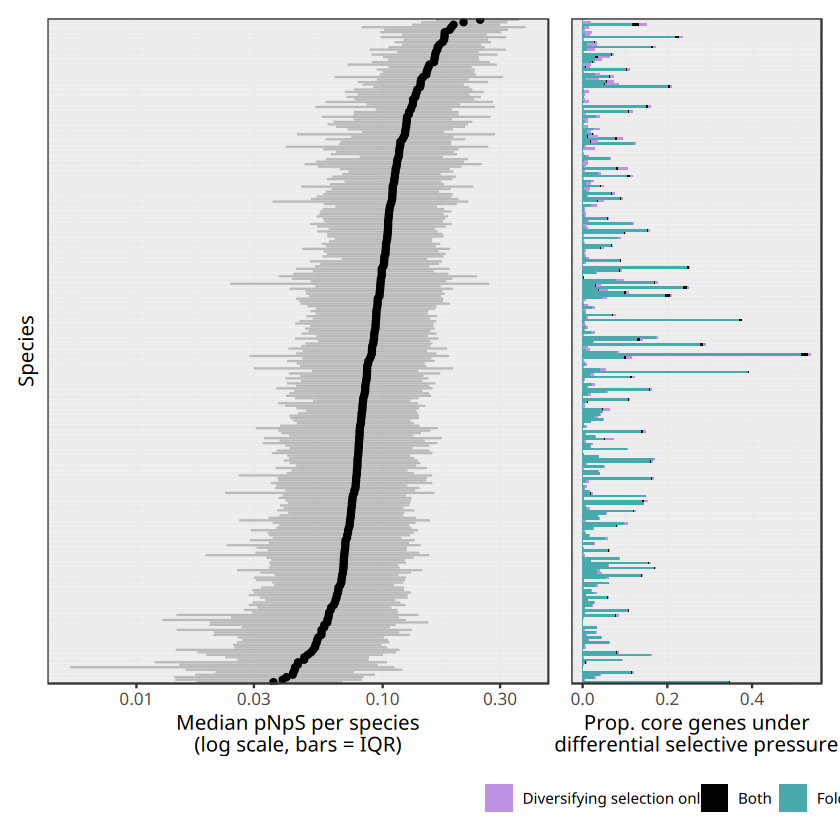

In [76]:
### Visualise species median pNpS values and proportion of genes exhibiting pNpS > 1
sp_summary_ordered <- sp_core_pnps_summary %>%
  mutate(Species = fct_reorder(Species, median_pNpS))

p_sp_pnps_medians <- sp_summary_ordered %>%
  ggplot(aes(x = median_pNpS, y = Species)) +
  geom_errorbarh(aes(xmin = q25, xmax = q75), height = 0, colour = "grey60", alpha = 0.6) +
  geom_point(size = 1.3) +
  scale_x_log10() +
  labs(
    x = "Median pNpS per species\n(log scale, bars = IQR)",
    y = "Species"
  ) +
  theme_bw() +
  theme(
    axis.text.y = element_blank(),
    axis.title.y = element_text(size = 12), 
    axis.ticks.y = element_blank(),
    axis.text.x = element_text(size = 10),
    axis.title.x = element_text(size = 12))

### Reshape to long format for stacking, using the SAME species ordering as the pNpS median panel
sp_combined_long <- sp_combined_summary %>%
  select(Species, prop_diversifying_only, prop_both, prop_foldshift_only) %>%
  pivot_longer(cols = starts_with("prop_"), names_to = "class", values_to = "prop") %>%
  mutate(
    class = recode(class,
      prop_diversifying_only = "Diversifying selection only",
      prop_both              = "Both",
      prop_foldshift_only    = "Fold-shift only"
    ),
    class = factor(class, levels = c("Diversifying selection only", "Both", "Fold-shift only")),
    Species = factor(Species, levels = levels(sp_summary_ordered$Species))  # match pNpS-median ordering
  )


p_sp_combined_signal <- sp_combined_long %>%
  ggplot(aes(x = prop, y = Species, fill = class)) +
  geom_col(width = 0.7) +
  scale_fill_manual(values = c(
    "Diversifying selection only" = "#bf92e4",
    "Both"                        = "#000000",
    "Fold-shift only"             = "#48AAAD"
  )) +
  labs(x = "Prop. core genes under\ndifferential selective pressure", y = NULL, fill = NULL) +
  theme_bw() +
  theme(
    axis.text.y = element_blank(),
    axis.title.y = element_blank(),
    axis.ticks.y = element_blank(),
    axis.text.x = element_text(size = 10),
    axis.title.x = element_text(size = 12),
    legend.position = "bottom"
  )

p_sp_pnps_summary = p_sp_pnps_medians+p_sp_combined_signal+plot_layout(widths=c(2,1))
p_sp_pnps_summary

# Export figures
ggsave(paste0(output_figures,"across_species/species_selected.pnps_summary_figure.pdf"), plot = p_sp_pnps_summary, device = "pdf", width=7, height=8, units = "in")
ggsave(paste0(output_figures,"across_species/species_selected.pnps_summary_figure.png"), plot = p_sp_pnps_summary, device = "png", width=7, height=8, units = "in")


## Investigate functions associated with pNpS >1 across species

In [78]:
species_subsp_gene_comp = fread(file = paste0(input_dir,"species_selected.gene_composition_w_annotations.tsv"), sep = "\t", header=T, check.names=F)

In [87]:
### Excract KEGG information and combine with pNpS categories
gene_to_kegg <- species_subsp_gene_comp %>%
  select(Species, Gene_catalog_rep, KEGG_ko) %>%
  distinct() %>%
  filter(!is.na(KEGG_ko), KEGG_ko != "-") %>%
  separate_rows(KEGG_ko, sep = "[,;]\\s*") %>% 
  distinct()

gene_categories <- gene_summary %>%
  filter(category != "Insufficient_data") %>%   # only genes that were actually eligible to be called diversifying
  select(Species, Gene_catalog_rep, category)

gene_cat_kegg <- gene_categories %>%
  inner_join(gene_to_kegg, by = c("Species", "Gene_catalog_rep"))

unique_kos <- gene_cat_kegg %>%
    select(KEGG_ko) %>%
    unique()

In [89]:
table(gene_categories$category)


               none        Species_wide Subspecies_specific 
             301698                 404                3913 

In [ ]:
#####
# Retrieve KEGG pathway and metabolism information for each KEGG ko
#####
dir.create(paste0(output_tables, "functional"), recursive = TRUE, showWarnings = FALSE)

# Bulk: every KO -> pathway ID link, all at once
ko_pathway_links <- KEGGREST::keggLink("pathway", "ko") %>%
  {tibble(KEGG_ko_full = names(.), pathway_id_full = unname(.))} %>%
  mutate(
    KEGG_ko    = str_remove(KEGG_ko_full, "^ko:"),
    pathway_id = str_remove(pathway_id_full, "^path:")
  ) %>%
  filter(str_detect(pathway_id, "^ko")) %>%   # keep KO-based reference pathways only
  select(KEGG_ko, pathway_id)

# Bulk: pathway ID -> name
pathway_names <- KEGGREST::keggList("pathway", "ko") %>%
  {tibble(pathway_id_full = names(.), pathway_name = unname(.))} %>%
  mutate(pathway_id = str_remove(pathway_id_full, "^path:")) %>%
  select(pathway_id, pathway_name)

ko_pathway_map <- ko_pathway_links %>%
  left_join(pathway_names, by = "pathway_id") %>%
  distinct()

In [82]:
### Retreive KEGG metabolism categories
library(httr)

resp <- httr::GET("https://rest.kegg.jp/get/br:ko00001")
raw_text <- httr::content(resp, as = "text", encoding = "UTF-8")
lines <- str_split(raw_text, "\n")[[1]]

current_A <- NA_character_
current_B <- NA_character_
brite_rows <- list()

for (ln in lines) {
  if (str_detect(ln, "^A")) {
    current_A <- ln %>% str_remove("^A") %>% str_remove_all("</?b>") %>% str_trim()
  } else if (str_detect(ln, "^B\\s")) {
    current_B <- ln %>% str_remove("^B\\s*") %>% str_trim()
  } else if (str_detect(ln, "^C\\s")) {
    path_match <- str_match(ln, "\\[PATH:(ko\\d+)\\]")
    pid <- if (!is.na(path_match[1, 2])) path_match[1, 2] else NA_character_
    if (!is.na(pid)) {
      brite_rows[[length(brite_rows) + 1]] <- tibble(
        category_A = current_A, category_B = current_B, pathway_id = pid
      )
    }
  }
}

brite_table <- bind_rows(brite_rows) %>% distinct()

In [91]:
### Add KEGG metabolism and pathway information to genes with pNpS >1
ko_pathway_map_catalogue <- ko_pathway_map %>%
  filter(KEGG_ko %in% unique_kos$KEGG_ko)

gene_kegg_pathways_and_metabolism <- gene_cat_kegg %>%
  inner_join(ko_pathway_map, by = "KEGG_ko") %>%
  distinct(Species, Gene_catalog_rep, category, pathway_id, pathway_name) %>%
  left_join(brite_table, by="pathway_id") %>%
  rename(
  KEGG_pathway_ID = pathway_id,
  KEGG_pathway_name = pathway_name,
  KEGG_category = category_A,
  KEGG_metabolism = category_B)

fwrite(gene_kegg_pathways_and_metabolism, file = paste0(output_tables, "across_species/species_selected.subspecies_gene_divers_pnps_to_kegg.tsv"), sep = "\t")

Warning message in inner_join(., ko_pathway_map, by = "KEGG_ko"):
“Detected an unexpected many-to-many relationship between `x` and `y`.
ℹ Row 3 of `x` matches multiple rows in `y`.
ℹ Row 5357 of `y` matches multiple rows in `x`.
ℹ If a many-to-many relationship is expected, set `relationship =
  "many-to-many"` to silence this warning.”


In [92]:
### Build the fold-shift classification, restricted to genes actually tested
gene_fold_shift_categories <- fc_results %>%
  filter(!is.na(p_adj)) %>%                     # keep only genes actually tested
  mutate(fold_shift_category = if_else(p_adj < 0.05, "significant", "not-significant")) %>%
  select(Species, Gene_catalog_rep, fold_shift_category)

### Join to KEGG annotation
gene_fold_shift_kegg <- gene_fold_shift_categories %>%
  inner_join(gene_to_kegg, by = c("Species", "Gene_catalog_rep"))

gene_kegg_fold_shift <- gene_fold_shift_kegg %>%
  inner_join(ko_pathway_map, by = "KEGG_ko") %>%
  distinct(Species, Gene_catalog_rep, fold_shift_category, pathway_id, pathway_name) %>%
  left_join(brite_table, by = "pathway_id") %>%
  rename(
    KEGG_pathway_ID   = pathway_id,
    KEGG_pathway_name = pathway_name,
    KEGG_category     = category_A,
    KEGG_metabolism   = category_B
  )

fwrite(gene_kegg_fold_shift, file = paste0(output_tables, "across_species/species_selected.gene_fold_shift_pnps_to_kegg.tsv"), sep = "\t")

Warning message in inner_join(., ko_pathway_map, by = "KEGG_ko"):
“Detected an unexpected many-to-many relationship between `x` and `y`.
ℹ Row 1 of `x` matches multiple rows in `y`.
ℹ Row 2021 of `y` matches multiple rows in `x`.
ℹ If a many-to-many relationship is expected, set `relationship =
  "many-to-many"` to silence this warning.”


In [ ]:
#####
# Generalized species-stratified permutation enrichment test.
# level_col: one of "KEGG_pathway_ID", "KEGG_category", "KEGG_metabolism"
# (or any other column in gene_kegg_pathways_and_metabolism you want to test at)
#####

run_kegg_enrichment <- function(data, level_col, category_of_interest,
                                  n_perm = 5000, min_genes = 10, seed = 1,
                                  exclude_overview_maps = TRUE) {

  level_data <- data %>%
    select(Species, Gene_catalog_rep, category, level_id = all_of(level_col)) %>%
    filter(!is.na(level_id), level_id != "-") %>%
    distinct()

  if (level_col == "KEGG_pathway_ID") {
    name_lookup <- data %>%
      distinct(level_id = KEGG_pathway_ID, level_name = KEGG_pathway_name)
    level_data <- level_data %>% left_join(name_lookup, by = "level_id")

    # Exclude KEGG's generic "global/overview maps" (e.g. ko01100 Metabolic
    # pathways) - these have no KEGG_category assignment and aren't
    # interpretable as coherent, specific biological pathways
    if (exclude_overview_maps) {
      overview_maps <- data %>%
        filter(is.na(KEGG_category)) %>%
        distinct(KEGG_pathway_ID) %>%
        pull(KEGG_pathway_ID)

      n_excluded <- sum(unique(level_data$level_id) %in% overview_maps)
      if (n_excluded > 0) {
        message("Excluding ", n_excluded, " generic/overview KEGG pathway(s) with no category assignment")
      }

      level_data <- level_data %>% filter(!level_id %in% overview_maps)
    }
  } else {
    level_data <- level_data %>% mutate(level_name = level_id)
  }

  pathway_obs <- level_data %>%
    mutate(id = paste(Species, Gene_catalog_rep)) %>%
    group_by(level_id, level_name) %>%
    summarise(
      n_genes_total          = n_distinct(id),
      n_obs                  = n_distinct(id[category == category_of_interest]),
      n_species_contributing = n_distinct(Species[category == category_of_interest]),
      .groups = "drop"
    ) %>%
    filter(n_genes_total >= min_genes)

  gene_lookup <- data %>% distinct(Species, Gene_catalog_rep, category)

  gene_level_lookup <- level_data %>%
    filter(level_id %in% pathway_obs$level_id) %>%
    distinct(Species, Gene_catalog_rep, level_id)

  set.seed(seed)
  perm_counts_mat <- matrix(NA_integer_, nrow = nrow(pathway_obs), ncol = n_perm,
                             dimnames = list(pathway_obs$level_id, NULL))

  for (b in seq_len(n_perm)) {
    perm_cat <- gene_lookup %>%
      group_by(Species) %>%
      mutate(category_perm = sample(category)) %>%
      ungroup() %>%
      select(Species, Gene_catalog_rep, category_perm)

    perm_summary <- gene_level_lookup %>%
      left_join(perm_cat, by = c("Species", "Gene_catalog_rep")) %>%
      mutate(id = paste(Species, Gene_catalog_rep)) %>%
      group_by(level_id) %>%
      summarise(n_perm = n_distinct(id[category_perm == category_of_interest]), .groups = "drop")

    perm_counts_mat[perm_summary$level_id, b] <- perm_summary$n_perm
  }

  perm_mean <- rowMeans(perm_counts_mat, na.rm = TRUE)
  perm_sd   <- apply(perm_counts_mat, 1, sd, na.rm = TRUE)

  pathway_obs %>%
    mutate(
      perm_mean = perm_mean, perm_sd = perm_sd,
      z_score = (n_obs - perm_mean) / perm_sd,
      p_perm  = (1 + rowSums(perm_counts_mat >= n_obs, na.rm = TRUE)) / (n_perm + 1),
      p_adj   = p.adjust(p_perm, method = "BH"),
      test_category = category_of_interest,
      test_level    = level_col
    ) %>%
    rename(!!paste0(level_col, "_id") := level_id,
           !!paste0(level_col, "_name") := level_name) %>%
    arrange(p_adj)
}

In [93]:
#####
# Run pathway enrichment analysis for 
#####
gene_kegg_fold_shift_renamed <- gene_kegg_fold_shift %>%
  rename(category = fold_shift_category)

enrich_pathway_pop  <- run_kegg_enrichment(gene_kegg_pathways_and_metabolism, "KEGG_pathway_ID", "Subspecies_specific", n_perm = 500)
enrich_pathway_spec <- run_kegg_enrichment(gene_kegg_pathways_and_metabolism, "KEGG_pathway_ID", "Species_wide", n_perm = 500)
enrich_pathway_foldshift    <- run_kegg_enrichment(gene_kegg_fold_shift_renamed, "KEGG_pathway_ID", "significant", n_perm = 500)

enrich_pathway_combined <- bind_rows(enrich_pathway_pop, enrich_pathway_spec)
fwrite(enrich_pathway_combined, paste0(output_tables, "across_species/species_selected.subspecies_gene_divers_pnps_kegg_pathway_enrichment_permutation_test.tsv"), sep = "\t")
fwrite(enrich_pathway_foldshift, paste0(output_tables, "across_species/species_selected.gene_fold_shift_pnps_kegg_pathway_enrichment_permutation_test.tsv"), sep = "\t")

Excluding 13 generic/overview KEGG pathway(s) with no category assignment

Excluding 13 generic/overview KEGG pathway(s) with no category assignment

Excluding 13 generic/overview KEGG pathway(s) with no category assignment



In [94]:
### Run Metabolism enrichment analysis
enrich_metabolism_pop  <- run_kegg_enrichment(gene_kegg_pathways_and_metabolism, "KEGG_metabolism", "Subspecies_specific", n_perm = 500)
enrich_metabolism_spec <- run_kegg_enrichment(gene_kegg_pathways_and_metabolism, "KEGG_metabolism", "Species_wide", n_perm = 500)
enrich_metabolism_foldshift <- run_kegg_enrichment(gene_kegg_fold_shift_renamed, "KEGG_metabolism", "significant", n_perm = 500)

enrich_metabolism_combined <- bind_rows(enrich_metabolism_pop, enrich_metabolism_spec)
fwrite(enrich_metabolism_combined, paste0(output_tables, "across_species/species_selected.subspecies_gene_divers_pnps_kegg_metabolism_enrichment_permutation_test.tsv"), sep = "\t")
fwrite(enrich_metabolism_foldshift, paste0(output_tables, "across_species/species_selected.gene_fold_shift_pnps_kegg_metabolism_enrichment_permutation_test.tsv"), sep = "\t")

In [95]:
#####
# Explore top recurring pathways/metabolisms under diversifying selection
#####
diversifying_genes_annotated <- gene_pop_status %>%
  filter(diversifying, reliable_gp) %>%
  inner_join(
    gene_kegg_pathways_and_metabolism %>%
      distinct(Species, Gene_catalog_rep, KEGG_pathway_ID, KEGG_pathway_name),
    by = c("Species", "Gene_catalog_rep")
  )

pathway_overview <- diversifying_genes_annotated %>%
  group_by(KEGG_pathway_ID, KEGG_pathway_name) %>%
  summarise(
    n_subspecies = n_distinct(paste(Species, Subspecies)),
    n_species = n_distinct(Species),
    n_genes = n_distinct(Gene_catalog_rep),
    .groups = "drop"
  ) %>%
  arrange(desc(n_subspecies))

overview_maps <- gene_kegg_pathways_and_metabolism %>%
  filter(is.na(KEGG_category)) %>%
  distinct(KEGG_pathway_ID) %>%
  pull(KEGG_pathway_ID)

pathway_overview_clean <- pathway_overview %>%
  filter(!KEGG_pathway_ID %in% overview_maps) 

head(pathway_overview_clean)

Warning message in inner_join(., gene_kegg_pathways_and_metabolism %>% distinct(Species, :
“Detected an unexpected many-to-many relationship between `x` and `y`.
ℹ Row 3 of `x` matches multiple rows in `y`.
ℹ Row 10119 of `y` matches multiple rows in `x`.
ℹ If a many-to-many relationship is expected, set `relationship =
  "many-to-many"` to silence this warning.”


KEGG_pathway_ID,KEGG_pathway_name,n_subspecies,n_species,n_genes
<chr>,<chr>,<int>,<int>,<int>
ko00790,Folate biosynthesis,40,32,42
ko03010,Ribosome,38,33,45
ko00230,Purine metabolism,31,26,27
ko00520,Amino sugar and nucleotide sugar metabolism,29,20,24
ko00860,Porphyrin metabolism,26,24,27
ko02010,ABC transporters,23,22,24


In [96]:
#####
# Explore whether signals of diversifying selection are found within pathways related to nutrient acquisition and metabolism
#####
nutrient_keywords <- c("nitrogen", "phosphonate", "phosphate", "phosphorus",
                        "ammonia", "urea", "nitrate", "phosphotransferase",
                        "sulfer", "methane")

nutrient_pathways <- gene_kegg_pathways_and_metabolism %>%
  distinct(KEGG_pathway_ID, KEGG_pathway_name) %>%
  filter(str_detect(tolower(KEGG_pathway_name), paste(nutrient_keywords, collapse = "|")))

nutrient_summary <- diversifying_genes_annotated %>%
  filter(KEGG_pathway_ID %in% nutrient_pathways$KEGG_pathway_ID) %>%
  group_by(KEGG_pathway_ID, KEGG_pathway_name) %>%
  summarise(
    n_subspecies = n_distinct(paste(Species, Subspecies)),
    n_species = n_distinct(Species),
    n_genes = n_distinct(Gene_catalog_rep),
    .groups = "drop"
  ) %>%
  arrange(desc(n_subspecies))

head(nutrient_summary)

KEGG_pathway_ID,KEGG_pathway_name,n_subspecies,n_species,n_genes
<chr>,<chr>,<int>,<int>,<int>
ko00680,Methane metabolism,19,15,16
ko00030,Pentose phosphate pathway,10,10,11
ko00910,Nitrogen metabolism,7,6,6
ko00562,Inositol phosphate metabolism,4,4,4
ko01310,Nitrogen cycle,2,1,1
ko00440,Phosphonate and phosphinate metabolism,1,1,1


# Create main manuscript figure

In [21]:
#####
# Panel 1: pNpS summary figure
#####
species_pnps <- fread(paste0(input_dir, "species_selected.pnps.tsv.gz"), sep = "\t", header = TRUE)
sp_core_gene_list <- fread(paste0(output_tables, "across_species/species_selected.species_core_gene_list.tsv"), sep = "\t", header = TRUE)
sp_all_gene_catalog <- fread(paste0(input_dir, "species_selected.gene_catalog.tsv"), sep = "\t", header = TRUE)
gene_combined_class <- fread(paste0(output_tables, "across_species/species_selected.genes_combined_selection_class.tsv"), sep = "\t", header = TRUE)

In [22]:
samp_to_subsp <- sp_all_gene_catalog %>% select(Sample, Subspecies, Species) %>% distinct()

sp_core_genes_pnps_filt <- species_pnps %>%
  filter(Species %in% samp_to_subsp$Species & Sample %in% samp_to_subsp$Sample) %>%
  select(Sample, Species, Gene_catalog_rep, pNpS) %>%
  left_join(samp_to_subsp, by = c("Species", "Sample")) %>%
  filter(is.finite(pNpS), !is.na(pNpS)) %>%
  distinct() %>%
  filter(Gene_catalog_rep %in% sp_core_gene_list$Gene_catalog_rep) %>%
  distinct()

rm(species_pnps); rm(sp_all_gene_catalog)   # free the large tables immediately

sp_core_gene_level <- sp_core_genes_pnps_filt %>%
  group_by(Species, Gene_catalog_rep) %>%
  summarise(mean_pNpS_gene = mean(pNpS, na.rm = TRUE), .groups = "drop")

sp_core_pnps_summary <- sp_core_gene_level %>%
  group_by(Species) %>%
  summarise(n_genes = n(), median_pNpS = median(mean_pNpS_gene, na.rm = TRUE),
            q25 = quantile(mean_pNpS_gene, 0.25, na.rm = TRUE), q75 = quantile(mean_pNpS_gene, 0.75, na.rm = TRUE)) %>%
  filter(n_genes > 100)

In [23]:
sp_combined_summary <- gene_combined_class %>%
  group_by(Species) %>%
  summarise(n_core_genes = n(),
            prop_diversifying_only = mean(combined_class == "Diversifying selection only"),
            prop_foldshift_only = mean(combined_class == "Fold-shift only"),
            prop_both = mean(combined_class == "Both"), .groups = "drop") %>%
  filter(n_core_genes > 100)

sp_summary_ordered <- sp_core_pnps_summary %>% mutate(Species = fct_reorder(Species, median_pNpS))

Warning message:
“`position_stack()` requires non-overlapping x intervals.”


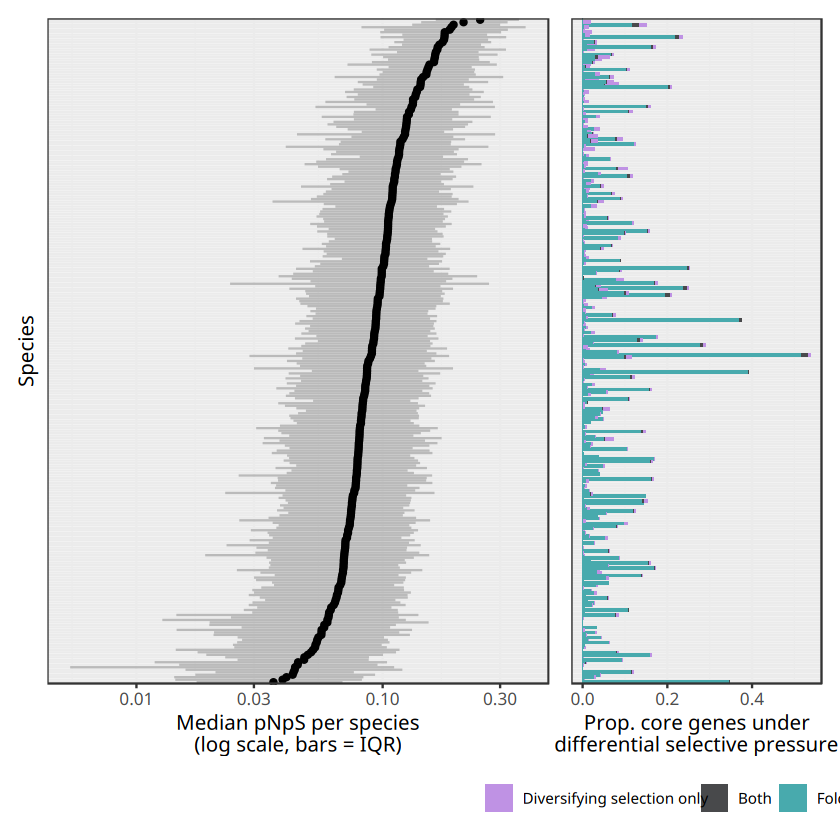

In [34]:
p_sp_pnps_medians <- sp_summary_ordered %>%
  ggplot(aes(x = median_pNpS, y = Species)) +
  geom_errorbarh(aes(xmin = q25, xmax = q75), height = 0, colour = "grey60", alpha = 0.6) +
  geom_point(size = 1.3) +
  scale_x_log10() +
  labs(x = "Median pNpS per species\n(log scale, bars = IQR)", y = "Species") +
  theme_bw() +
  theme(axis.text.y = element_blank(), axis.title.y = element_text(size = 12), axis.ticks.y = element_blank(),
        axis.text.x = element_text(size = 10), axis.title.x = element_text(size = 12))

sp_combined_long <- sp_combined_summary %>%
  select(Species, prop_diversifying_only, prop_both, prop_foldshift_only) %>%
  pivot_longer(cols = starts_with("prop_"), names_to = "class", values_to = "prop") %>%
  mutate(class = recode(class, prop_diversifying_only = "Diversifying selection only", prop_both = "Both", prop_foldshift_only = "Fold-shift only"),
         class = factor(class, levels = c("Diversifying selection only", "Both", "Fold-shift only")),
         Species = factor(Species, levels = levels(sp_summary_ordered$Species)))

p_sp_combined_signal <- sp_combined_long %>%
  ggplot(aes(x = prop, y = Species, fill = class)) +
  geom_col(width = 1.1) +
  scale_fill_manual(values = c("Diversifying selection only" = "#bf92e4", "Both" = "#48494B", "Fold-shift only" = "#48AAAD")) +
  labs(x = "Prop. core genes under\ndifferential selective pressure", y = NULL, fill = NULL) +
  theme_bw() +
  theme(axis.text.y = element_blank(), axis.title.y = element_blank(), axis.ticks.y = element_blank(),
        axis.text.x = element_text(size = 10), axis.title.x = element_text(size = 12), legend.position = "bottom")

p_sp_pnps_summary <- p_sp_pnps_medians + p_sp_combined_signal + plot_layout(widths = c(2, 1))
p_sp_pnps_summary

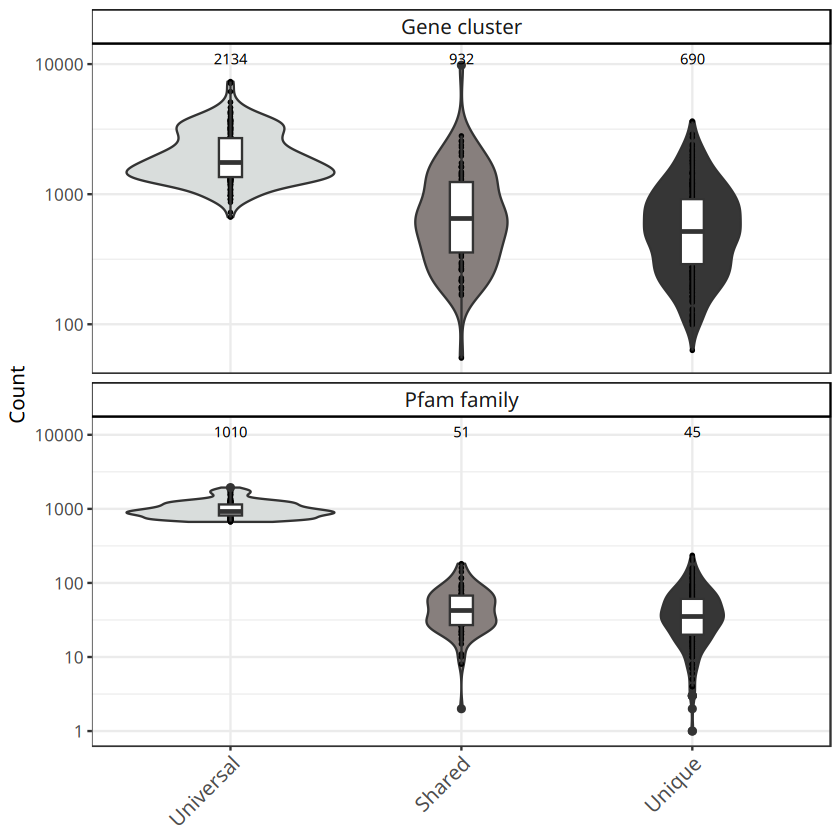

In [25]:
#####
# Panel 2: gene/pfam count violins
#####
subspecies_genes_and_pfams_categories_counts <- fread(
  paste0(output_tables, "across_species/species_selected.subspecies.core_gene_and_pfam_counts.tsv"),
  sep = "\t", header = TRUE
) %>%
  mutate(Gene_level = factor(Gene_level, levels = c("Gene cluster", "Pfam family")),
         Gene_group = factor(Gene_group, levels = c("Universal", "Shared", "Unique")))

subspecies_genes_and_pfams_categories_median_vals <- subspecies_genes_and_pfams_categories_counts %>%
  group_by(Gene_level, Gene_group) %>%
  summarise(mean_vals = mean(Count), .groups = "drop")

species_subsp_gene_comp_counts_violin <- subspecies_genes_and_pfams_categories_counts %>%
  ggplot(aes(x = Gene_group, y = Count)) +
    geom_violin(aes(fill = Gene_group)) +
    geom_point(size = 0.5) +
    geom_boxplot(width = 0.1, linewidth = 0.5) +
    geom_text(data = subspecies_genes_and_pfams_categories_median_vals,
              aes(x = Gene_group, y = 11000, label = round(mean_vals, 0)),
              inherit.aes = FALSE, size = 3, color = "black") +
    scale_fill_manual(values = c("Universal" = "#D9DDDC", "Shared" = "#877F7D", "Unique" = "#363636")) +
    facet_wrap(Gene_level~., scales = "free_y", nrow = 2) +
    scale_y_log10() +
    theme_bw() +
    theme(
      legend.position = "none", 
      legend.title = element_blank(), 
      legend.text = element_text(size = 12),
      strip.background = element_rect(fill = "white", colour = "black"), 
      strip.text = element_text(size = 12),
      axis.text.y = element_text(size = 10), 
      axis.title.y = element_text(size = 12),
      axis.text.x = element_text(size = 12, angle = 45, hjust = 1), 
      axis.title.x = element_blank()) +
    guides(fill = guide_legend(ncol = 3))

species_subsp_gene_comp_counts_violin

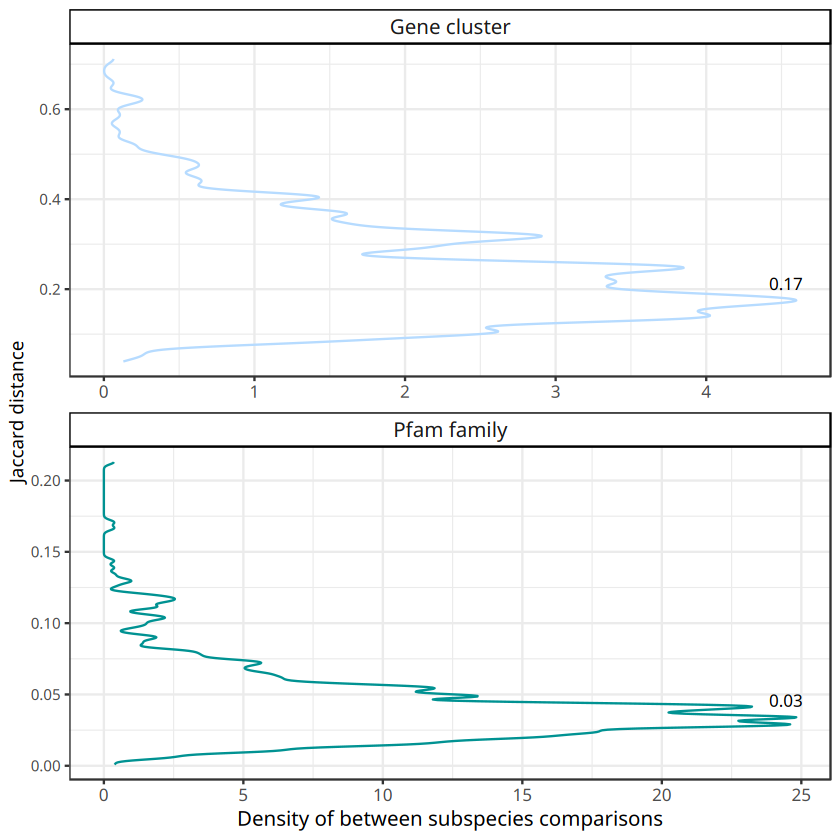

In [26]:
#####
# Panel 3: Jaccard density plot
#####
subspecies_jaccard_distances_df <- fread(paste0(output_tables, "across_species/species_selected.subspecies.gene_jaccard_distances.tsv"), sep = "\t", header = TRUE)
subspecies_pfam_jaccard_distances_df <- fread(paste0(output_tables, "across_species/species_selected.subspecies.pfam_jaccard_distances.tsv"), sep = "\t", header = TRUE)

gene_and_pfam_dist_between <- bind_rows(
  subspecies_jaccard_distances_df %>% mutate(Gene_level = "Gene cluster"),
  subspecies_pfam_jaccard_distances_df %>% mutate(Gene_level = "Pfam family")
) %>%
  filter(Subspecies_one != Subspecies_two)

gene_comp_density <- ggplot(gene_and_pfam_dist_between, aes(x = Jaccard_distance, colour = Gene_level)) +
  facet_wrap(Gene_level ~ ., scales = "free", nrow = 2) +
  geom_density(adjust = 1/3) +
  scale_colour_manual(values = c("Gene cluster" = "#b6dbff", "Pfam family" = "#009292")) +
  theme_bw() +
  labs(x = "Jaccard distance", y = "Density of between subspecies comparisons") +
  coord_flip() +
  theme(
    axis.text.x = element_text(size = 10), 
    axis.title.x = element_text(size = 12),
    strip.text.x = element_text(size = 12), 
    strip.background.x = element_rect(fill = "white", colour = "black"),
    legend.position = "none", 
    legend.title = element_blank(), 
    legend.text = element_text(size = 12))

dens_data <- ggplot_build(gene_comp_density)$data[[1]]
peak_labels <- dens_data %>% group_by(group) %>% slice_max(density, n = 1) %>% ungroup()
category_levels <- unique(gene_and_pfam_dist_between$Gene_level)
peak_labels$Gene_level <- factor(category_levels[peak_labels$group], levels = category_levels)

subspecies_gene_clust_pfam_jaccard_density <- gene_comp_density +
  geom_text(data = peak_labels, aes(x = x, y = density, label = round(x, 2)),
            colour = "#000000", inherit.aes = FALSE, vjust = -0.8, hjust = 0.8, size = 3.5, show.legend = FALSE)
subspecies_gene_clust_pfam_jaccard_density

In [27]:
#####
# Panel 4: SNV vs. Jaccard GAM scatter (only the cheap final refit - no
# lm/poly model comparison needed here, that was exploratory)
#####
jaccard_gene_sample_df <- fread(paste0(output_tables, "across_species/species_selected.subspecies.sample_gene_jaccard_distances.tsv"), sep = "\t", header = TRUE)
jaccard_pfam_sample_df <- fread(paste0(output_tables, "across_species/species_selected.subspecies.sample_pfam_jaccard_distances.tsv"), sep = "\t", header = TRUE)

subspecies_sample_snv_dist <- fread(paste0(input_dir, "POPULATIONS-DIST-SUMMARY.tsv.gz"), sep = "\t", header = TRUE, check.names = FALSE) %>%
  mutate(Subspecies_one = paste0("Subspecies_", cluster_1),
         Subspecies_two = paste0("Subspecies_", cluster_2),
         Category = case_when(comp == "Same population" ~ "Same subspecies",
                               comp == "Different populations" ~ "Different subspecies")) %>%
  rename(Species = species, Sample_one = sample_1, Sample_two = sample_2, SNV_distance = dist)

subspecies_gene_and_pfam_dist <- bind_rows(
  jaccard_gene_sample_df %>% mutate(Gene_level = "Gene cluster"),
  jaccard_pfam_sample_df %>% mutate(Gene_level = "Pfam family")
) %>%
  mutate(Category = case_when(Subspecies_one == Subspecies_two ~ "Same subspecies", TRUE ~ "Different subspecies"))

subspecies_gene_and_pfam_diff_dist <- subspecies_gene_and_pfam_dist %>%
  filter(Category == "Different subspecies") %>%
  aggregate(Jaccard_distance ~ Species + Subspecies_one + Subspecies_two + Gene_level, data = ., FUN = mean)

species_subspsnv_diff_dist <- subspecies_sample_snv_dist %>%
  filter(Category == "Different subspecies") %>%
  aggregate(SNV_distance ~ Species + Subspecies_one + Subspecies_two, data = ., FUN = mean)

pairwise_jaccard <- subspecies_gene_and_pfam_diff_dist %>%
  left_join(species_subspsnv_diff_dist %>% select(Species, Subspecies_one, Subspecies_two, SNV_distance),
            by = c("Species", "Subspecies_one", "Subspecies_two"))

In [28]:
gene_data <- pairwise_jaccard %>% filter(Gene_level == "Gene cluster", !is.na(SNV_distance), !is.na(Jaccard_distance))
pfam_data <- pairwise_jaccard %>% filter(Gene_level == "Pfam family", !is.na(SNV_distance), !is.na(Jaccard_distance))

gene_data_trimmed <- gene_data %>% filter(SNV_distance <= quantile(SNV_distance, 0.99)) %>% mutate(Species = as.factor(Species))
pfam_data_trimmed <- pfam_data %>% filter(SNV_distance <= quantile(SNV_distance, 0.99)) %>% mutate(Species = as.factor(Species))

gene_gam_trimmed <- mgcv::gam(Jaccard_distance ~ s(SNV_distance, k = 5) + s(Species, bs = "re"), data = gene_data_trimmed, method = "ML")
pfam_gam_trimmed <- mgcv::gam(Jaccard_distance ~ s(SNV_distance, k = 5) + s(Species, bs = "re"), data = pfam_data_trimmed, method = "ML")


In [29]:
get_gam_smooth_curve <- function(gam_fit, data, species_col = "Species") {
  xrange <- seq(min(data$SNV_distance), max(data$SNV_distance), length.out = 200)
  newdata <- data.frame(SNV_distance = xrange, Species = factor(data[[species_col]][1], levels = levels(data[[species_col]])))
  pred <- predict(gam_fit, newdata = newdata, se.fit = TRUE, exclude = "s(Species)", newdata.guaranteed = TRUE)
  data.frame(SNV_distance = xrange, fit = pred$fit, lower = pred$fit - 1.96 * pred$se.fit, upper = pred$fit + 1.96 * pred$se.fit)
}

gene_trimmed_curve <- get_gam_smooth_curve(gene_gam_trimmed, gene_data_trimmed) %>% mutate(Gene_level = "Gene cluster")
pfam_trimmed_curve <- get_gam_smooth_curve(pfam_gam_trimmed, pfam_data_trimmed) %>% mutate(Gene_level = "Pfam family")

trimmed_curves <- bind_rows(gene_trimmed_curve, pfam_trimmed_curve) %>%
  mutate(Gene_level = factor(Gene_level, levels = c("Gene cluster", "Pfam family")))

In [30]:
r2_gam_manual <- function(gam_fit, data) {
  pred_fixed <- predict(gam_fit, newdata = data, exclude = "s(Species)")
  var_fixed <- var(pred_fixed)
  vc <- gam.vcomp(gam_fit)
  species_row <- grep("Species", rownames(vc), value = TRUE)[1]
  var_random <- vc[species_row, "std.dev"]^2
  var_resid <- gam_fit$sig2
  total_var <- var_fixed + var_random + var_resid
  data.frame(marginal_r2 = var_fixed / total_var, conditional_r2 = (var_fixed + var_random) / total_var)
}

get_gam_annotation <- function(gam_fit, data, label) {
  s <- summary(gam_fit); r2s <- r2_gam_manual(gam_fit, data)
  data.frame(Gene_level = label, marginal_r2 = r2s$marginal_r2, conditional_r2 = r2s$conditional_r2,
             edf = s$s.table["s(SNV_distance)", "edf"], p.value = s$s.table["s(SNV_distance)", "p-value"])
}

panel_annotations <- bind_rows(
  get_gam_annotation(gene_gam_trimmed, gene_data_trimmed, "Gene cluster"),
  get_gam_annotation(pfam_gam_trimmed, pfam_data_trimmed, "Pfam family")
) %>%
  mutate(Gene_level = factor(Gene_level, levels = c("Gene cluster", "Pfam family")),
         p_label = ifelse(p.value < 2.2e-16, "p < 2.2e-16", paste0("p = ", signif(p.value, 3))),
         label = paste0("Marginal R\u00B2 = ", round(marginal_r2, 3),
                         "\nConditional R\u00B2 = ", round(conditional_r2, 3), "\n  ", p_label))


Standard deviations and 0.95 confidence intervals:

                     std.dev        lower        upper
s(SNV_distance) 2.545236e+03 594.03657458 1.090544e+04
s(Species)      1.055029e-01   0.09581999 1.161642e-01
scale           6.244864e-02   0.05987139 6.513684e-02

Rank: 3/3

Standard deviations and 0.95 confidence intervals:

                     std.dev        lower        upper
s(SNV_distance) 724.47992607 239.12477512 2.194968e+03
s(Species)        0.02456746   0.02220176 2.718523e-02
scale             0.01672262   0.01603115 1.744391e-02

Rank: 3/3


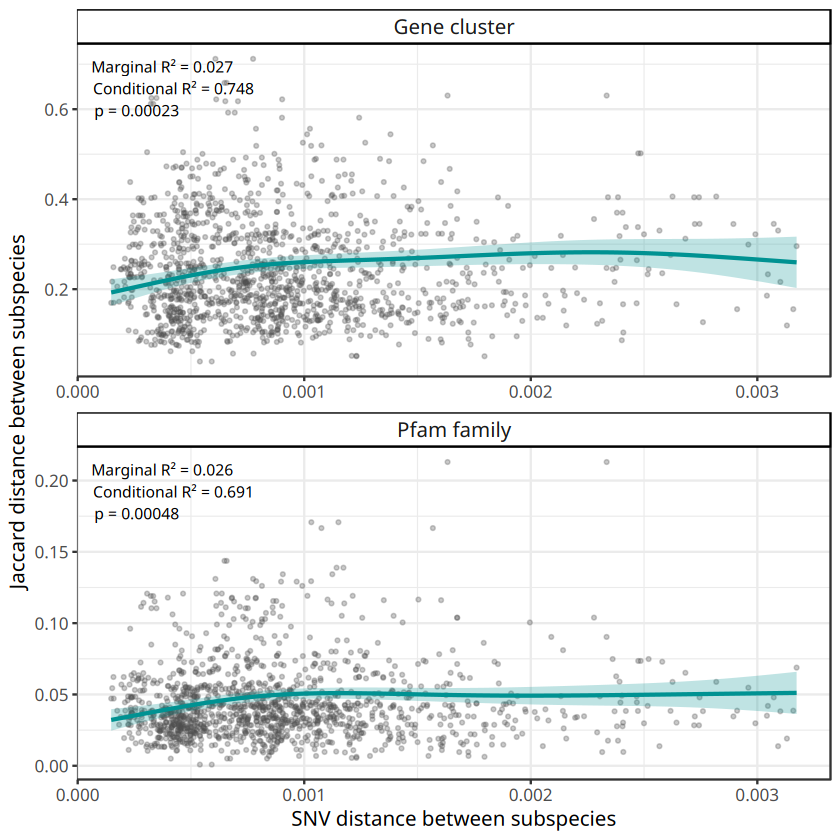

In [31]:
gene_cutoff <- quantile(gene_data$SNV_distance, 0.99)
pfam_cutoff <- quantile(pfam_data$SNV_distance, 0.99)
pairwise_snv_jaccard_plotted <- pairwise_jaccard %>%
  mutate(Gene_level = factor(Gene_level, levels = c("Gene cluster", "Pfam family"))) %>%
  filter((Gene_level == "Gene cluster" & SNV_distance <= gene_cutoff) |
         (Gene_level == "Pfam family" & SNV_distance <= pfam_cutoff))

snv_jaccard_gam_panel <- ggplot() +
  geom_point(data = pairwise_snv_jaccard_plotted, aes(x = SNV_distance, y = Jaccard_distance), alpha = 0.3, size = 0.7, colour = "grey30") +
  geom_ribbon(data = trimmed_curves, aes(x = SNV_distance, ymin = lower, ymax = upper), alpha = 0.25, fill = "#009292") +
  geom_line(data = trimmed_curves, aes(x = SNV_distance, y = fit), colour = "#009292", linewidth = 0.9) +
  geom_text(data = panel_annotations, aes(x = -Inf, y = Inf, label = label), hjust = -0.1, vjust = 1.3, size = 3.2, inherit.aes = FALSE) +
  facet_wrap(Gene_level ~ ., scales = "free", nrow = 2) +
  theme_bw() +
  labs(x = "SNV distance between subspecies", y = "Jaccard distance between subspecies") +
  theme(
    strip.background = element_rect(fill = "white", colour = "black"), 
    strip.text = element_text(size = 12),
    axis.text = element_text(size = 10), 
    axis.title = element_text(size = 12))
snv_jaccard_gam_panel


Warning message:
“`position_stack()` requires non-overlapping x intervals.”
Warning message:
“`position_stack()` requires non-overlapping x intervals.”
Warning message:
“`position_stack()` requires non-overlapping x intervals.”


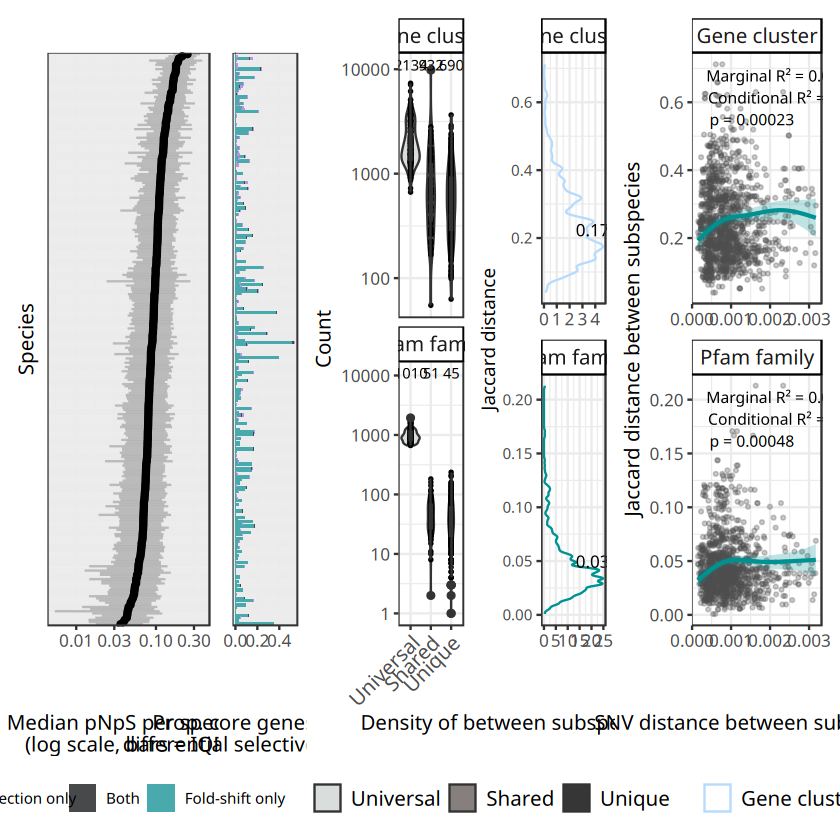

In [35]:
#####
# Final assembly
#####

final_integrated_figure <- p_sp_pnps_medians +
  p_sp_combined_signal +
  species_subsp_gene_comp_counts_violin +
  subspecies_gene_clust_pfam_jaccard_density +
  snv_jaccard_gam_panel +
  plot_layout(widths = c(1.25, 0.5, 0.5, 0.5, 1), nrow = 1, guides = "collect") &
  theme(legend.position = "bottom")

final_integrated_figure

ggsave(paste0(output_figures, "Figure_3_mechanisms_of_diversification.pdf"), plot = final_integrated_figure, device = "pdf", width = 14, height = 9, units = "in")
ggsave(paste0(output_figures, "Figure_3_mechanisms_of_diversification.png"), plot = final_integrated_figure, device = "png", width = 14, height = 9, units = "in")